Sept 27, 2024

# D208: Predictive Modeling | Task 1: Linear Regression Modeling

## Hannah R. Bergman
Student ID: 001539744 | WGU Email: [hbergm3@wgu.edu](mailto:hbergm3@wgu.edu)

---
Table of Contents:
- [Part I: Research Question](#1)
    - [A1. Research Question](#a1)
    - [A2. Goals of Data Analysis](#a2) 
- [Part II: Method Justification](#2)
    - [B1. Assumptions of Multiple Linear Regression Model](#b1)
    - [B2. Python Benefits](#b2)
    - [B3. Multiple Linear Regression Technique Justification](#b3)
- [Part III: Data Preparation](#3)
    - [C1. Data Cleaning Goals & Steps](#c1)
    - [C2. Summary Statistics](#c2)
    - [C3. Univariate & Bivariate Visualizations](#c3)
    - [C4. Data Transformation Goals & Steps](#c4)
    - [C5. Prepared Data Set](#c5)
- [Part IV: Model Comparison & Analysis](#4)
    - [D1. Initial Multiple Linear Regression Model](#d1)
    - [D2. Feature Selection Procedure](#d2)
    - [D3. Reduced Linear Regression Model](#d3)
    - [E1. Data Analysis Process](#e1)
    - [E2. Output & Calculations of Analysis](#e2)
    - [E3.Implementation of Linear Regression Models](#e3)
- [Part V: Data Summary & Implications](#5)
    - [F1. Results of Data Analysis](#f1)
        - [A. Regression Equation](#f1a)
        - [B. Interpretation of the Coefficients of the Reduced Model](#f1b)
        - [C. Statistical and Practical Significance of the Reduced Model](#f1c)
        - [D. Limitations of the Analysis](#f1d)
    - [F2. Recommendation](#f2)
- [Part VI: Demonstration](#6)
     - [G: Panopto Video Recording](#g) 
     - [H: Data & Code Sources](#h)  
     - [I: References](#i) 
 ---

<a id="1"></a>
# Part I. Research Question

<a id="a1"></a>
## A1. Research Question

<mark>Which patient characteristics or comorbidities most significantly influence their length of stay in our hospital?</mark>

----
Definitions: 
- Patient characteristics include demographic factors like age, income, and gender. We also consider lifestyle factors such as weight and family size, along with health-related data like complication risk, reason for admission, and average daily charges.

- Comorbidities refer to pre-existing medical conditions including diabetes, high blood pressure, back pain, asthma, and a history of stroke.

---- 
Variable Selection: 

- Target Continous Dependent Variable (Y): 
Initial_days (representing length of stay) 

- Explanatory Variables (X): 
Age, Income, TotalCharge (average daily charge), Children (children in household), Gender, Complication_risk (complication risk level), Initial_admin (admission type), Overweight, Diabetes, HighBlood (high blood pressure), BackPain, Asthma, Stroke. 

<a id="a2"></a>
## A2. Goals of Data Analysis

The primary goal of this data analysis is to identify the most influential factors affecting patient length of stay in our hospital. Using multiple regression analysis, we will examine our dataset to determine which independent variables, such as patient demographics, medical conditions, and lifestyle factors, have the greatest impact on the dependent variable: length of stay (Initial_days).

The insights drawn from this analysis can help inform hospital practices, enabling us to deliver more personalized care, potentially decreasing overall hospital stays and enhancing patient outcomes. By targeting the most significant contributing factors, we can optimize resource allocation, accelerating recovery times and mitigating the financial strain associated with extended hospitalizations.

<a id="2"></a>
# Part II. Method Justification

<a id="b1"></a>
## B1. Assumptions of Our Multiple Linear Regression Model 

In multiple linear regression, we use statistics to explore how one variable (the dependent variable, y) is influenced by two or more other variables (independent variables, X). We attempt to build a model based on the assumption that the relationship between these variables is straightforward and linear, much like a straight line (Statology, 2020). To get the most accurate and reliable results, the data should align with four key assumptions of this model:

#### Assumption 1: Linearity (Linear Correlation)
There must be a linear correlation between our independent variable (x) and dependent variable (y). 

#### Assumption 2: Absence of Multicollinearity
Multicollinearity, a condition that "occurs when two or more independent variables have a high correlation with one another in a regression model", can significantly impair the performance of our multiple linear regression model. Presence of multicollinearity makes it "difficult to determine the individual effect of each independent variable on the dependent variable", leading to inflated standard errors and unreliable coefficient estimates. Identifying multicollinearity is essential to prevent distorted results and ensure model interpretability. One effective method "to detect multicollinearity is to calculate the variance inflation factor (VIF) for each independent variable" (Bhandari, 2024). 

#### Assumption 3: Homoscedasticity 
Ideally, the mistakes our model makes (the differences between the actual data points and the predictions) should be spread out equally, regardless of the value of the independent variable (x). This spread of data staying the same across all values of the independent variable is what’s called homoscedasticity. If the spread of the mistakes changes as the independent variable (x) goes up or down, it becomes a problem. This is called heteroscedasticity and can negatively affect our analysis by causing the regression model to become less dependable, making our results invalid (Mahmood, 2021) .

#### Assumption 4: Normality of Residuals
This assumption refers to whether the errors (the difference between actual values and predicted values) are spread out normally around zero. A normal distribution, often visualized as a bell curve, signifies the model effectively captures the main trends and relationships within the data. Deviations from normality might indicate missing crucial variables, or potentially signal violations of other regression model assumptions (PennState, 2018).

<a id="b2"></a>
## B2. Python Benefits

For this analysis, I'll be using Python - a programming language well suited for data science tasks like this. Python offers an extensive collection of powerful libraries specifically designed to make working with data easier.

Specific Benefits:
- **Effortless Data Management:** Python's specialized libraries help make our data management process faster and more reliable. For example, the Python Pandas library allows us to better visualize and work with our data in a more efficient, human-readable spreadsheet format using DataFrames. Paired with NumPy, we can perform calculations, clean up our data, and get it ready for our regression analysis quickly. 

- **Advanced Statistics Made Easy:** Python also offers access to advanced statistical and machine learning libraries like Statsmodels and Sklearn. These allow us to generate detailed summaries of our regression models, including our R-squared values, F-statistics, p-values, coefficients, and standard errors, with ease. 

In [1]:
# Python's specialized libraries + their intended uses

import pandas as pd # for data manipulation
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # used on top of matplotlib for even 'prettier' data visualization
sns.set()
import statsmodels.api as sm # for statistical modeling
from statsmodels.stats.outliers_influence import variance_inflation_factor # for checking for problems such as multicolinearity using the VIF
from sklearn import preprocessing # for transforming our data further

In [2]:
# Utilize the Pandas library to create a dataframe (df) to visualize our data at a high level
df = pd.read_csv('medical_clean.csv')

# Preview the dataframe (displaying all columns)
pd.set_option("display.max_columns", None)
df.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,2951,Suburban,America/Chicago,"Psychologist, sport and exercise",1,53,86575.93,Divorced,Male,No,19.141466,6,0,0,No,Emergency Admission,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Blood Work,10.585770,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,11303,Urban,America/Chicago,Community development worker,3,51,46805.99,Married,Female,No,18.940352,4,2,1,No,Emergency Admission,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No,Intravenous,15.129562,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,17125,Suburban,America/Chicago,Chief Executive Officer,3,53,14370.14,Widowed,Female,No,18.057507,4,1,0,No,Elective Admission,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No,Blood Work,4.772177,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,2162,Suburban,America/Chicago,Early years teacher,0,78,39741.49,Married,Male,No,16.576858,4,1,0,No,Elective Admission,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes,Blood Work,1.714879,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,5287,Rural,America/New_York,Health promotion specialist,1,22,1209.56,Widowed,Female,No,17.439069,5,0,2,Yes,Elective Admission,No,No,Low,No,No,No,Yes,No,No,Yes,No,No,CT Scan,1.254807,2113.073274,3716.525786,2,1,3,3,5,3,4,3


<a id="b3"></a>
## B3. Multiple Linear Regression Technique Justification

To understand what factors most significantly influence how long patients stay in the hospital, multiple linear regression is ideal because it lets us analyze the combined effects of <b>multiple independent variables<b> on a single continuous dependent variable.

In our case, our independent variables encompass various patient charactertics like demographics (age, income, gender), lifestyle choices (weight, number of children) and other health data (complication risk, admission type),  as well as pre-existing comorbidities (diabetes, high blood pressure, back pain, asthma, stroke). Our dependent variable is the continuous length of stay. 

Multiple linear regression is the best technique as it goes beyond looking at each factor in isolation. It allows us to assess how each variable contributes to the length of stay, considering their interactions. This comprehensive approach provides a clearer picture of how these different factors work together to predict how long patients remain hospitalized.

<a id="3"></a>
# Part III. Data Preparation

<a id="c1"></a>
## C1. Data Cleaning Goals & Steps

### Goals
Our data cleaning goals include ensuring data quality by addressing missing values, correcting anomalies, and ensuring data types are appropriate for our analysis. We aim to prepare a dataset that accurately reflects the variables of interest for our research question.

### Steps

#### Detect & Handle Missing Values: 
Check for and address any missing values in the dataset for our variables of interest.

1. **Identification:** 
Utilize the isnull() function to check for missing values in our dataset, pairing this with the sum() method to return the total number of missing values in each column.
2. **Investigation:** 
If any missing data is present, determine the reason. Consider factors such as data collection errors, data entry mistakes, or inherent limitations in the data source.
3. **Handling**: Address missing values, if present. Choose an appropriate handling method based on the reason for the missing data and context of our analysis. If a high proportion of missing values is present, we may want to consider removing those rows or columns so long as doing so doesn't significantly impact our analysis. If preserving a substantial portion of the dataset is crucial, imputation techniques such as mean, median, or mode can be employed to fill in missing data points. If our missing values are random and unlikely to affect our analysis, we can also choose to ignore them (although this option is not preferred).

Step 1. **Identification**

In [3]:
# Check for missing values in our dataset
df.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

Step 2. **Investigation**

As we can see from the result above, there appears to be no missing values in our dataset. 

Step 3. **Handling**

The dataset does not have missing values for our variables of interest.

----

#### Outlier Detection & Handling:
Identify and address data points that significantly deviate from the expected pattern or range in our dataset. These outliers can skew our analysis results and lead to inaccurate conclusions.

1. **Identification:** Identify outliers using visual techniques to identify points that fall outside the normal distribution. 
2. **Investigation:** Determine the cause of the outlier (whether it's due to errors, anomalies, or legitimate extreme values.
3. **Handling**: Decide on the appropriate action based on the cause and context of any outlier(s) we find.

Step 1. **Identification**

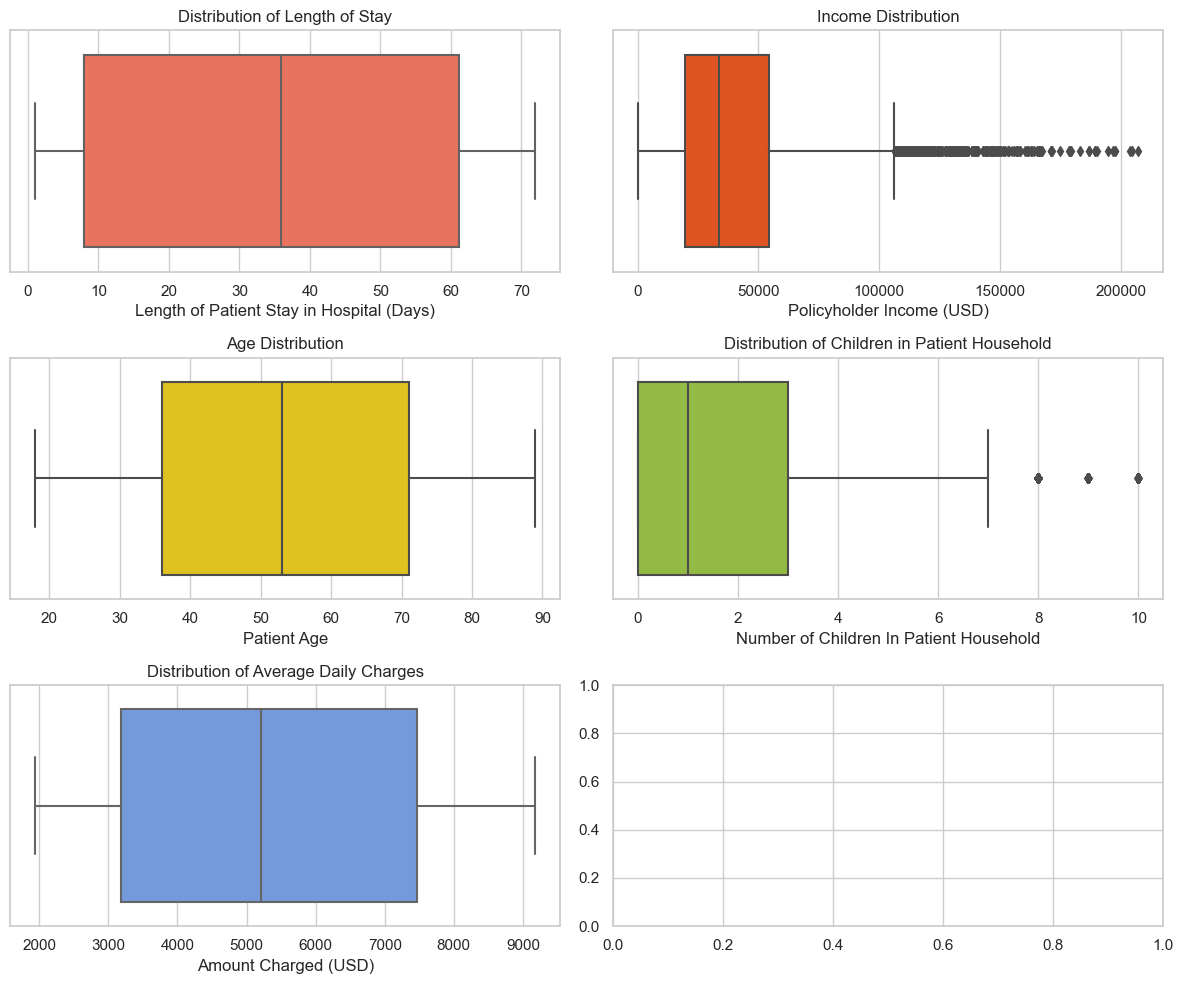

In [4]:
# Set plot style
sns.set_style("whitegrid")
sns.color_palette("Set2")

# Plot boxplots for numeric variables to easily identify outliers at a glance
fig, ax = plt.subplots(3, 2, figsize=(12, 10))

# Initial_days (length of stay)
sns.boxplot(x=df['Initial_days'], ax=ax[0,0], color='tomato')
ax[0,0].set_title('Distribution of Length of Stay')
ax[0,0].set_xlabel('Length of Patient Stay in Hospital (Days)')

# Income 
sns.boxplot(x=df['Income'], ax=ax[0,1], color='orangered')
ax[0,1].set_title('Income Distribution')
ax[0,1].set_xlabel('Policyholder Income (USD)')

# Age 
sns.boxplot(x=df['Age'], ax=ax[1, 0], color='gold')
ax[1,0].set_title('Age Distribution')
ax[1,0].set_xlabel('Patient Age')

# Children
sns.boxplot(x=df['Children'], ax=ax[1, 1], color='yellowgreen')
ax[1,1].set_title('Distribution of Children in Patient Household')
ax[1,1].set_xlabel('Number of Children In Patient Household')

# Daily charge
sns.boxplot(x=df['TotalCharge'], ax=ax[2, 0], color='cornflowerblue')
ax[2,0].set_title('Distribution of Average Daily Charges')
ax[2,0].set_xlabel('Amount Charged (USD)')

plt.tight_layout()
plt.show()

Step 2. **Investigation**

Length of stay, age, and average daily charge appear to have fairly normal distributions without significant outliers. Income and number of chilren, however, show a wider range with some high-end outliers. These outliers represent higher-income individuals and families with more children and are not necessarily errors or unrealistic values; they simply reflect the income and family-size diversity among the patient population. <br>

Step 3: **Handling**

Given the nature of our research question, these outliers in income and number of children may still provide valuable insights into how income levels and family-size affect length of stay so we'll retain them for our analysis.

----

#### Check Data Types

Verify the data type of each column to ensure data consistency and compatibility with multiple linear regression. 

1. **Identification:** Determine the data type of each column using the dtype function.
2. **Verification:** Check if the data types align with the expected values and analysis requirements.
3. **Handling**: Determine if data type correction is needed. 

Step 1. **Identification**

In [5]:
# Check the data type of each column
df.dtypes

CaseOrder               int64
Customer_id            object
Interaction            object
UID                    object
City                   object
State                  object
County                 object
Zip                     int64
Lat                   float64
Lng                   float64
Population              int64
Area                   object
TimeZone               object
Job                    object
Children                int64
Age                     int64
Income                float64
Marital                object
Gender                 object
ReAdmis                object
VitD_levels           float64
Doc_visits              int64
Full_meals_eaten        int64
vitD_supp               int64
Soft_drink             object
Initial_admin          object
HighBlood              object
Stroke                 object
Complication_risk      object
Overweight             object
Arthritis              object
Diabetes               object
Hyperlipidemia         object
BackPain  

Step 2. **Verification**

The data types of this dataset appear mostly suitable for our analysis. 
- **Continuous Variables:** Initial_days (float), Income (float), Age (int), and Children (int) are appropriately defined as numerical data types, allowing for quantitative analysis.
- **Categorical Variables:** Overweight, Diabetes, HighBlood, BackPain, Asthma, Stroke, Gender, Complication_risk, and Initial_admin are in a format suitable for encoding into categorical representations, making them compatible with categorical analysis techniques.


Step 3. **Handling**

To ensure data quality and compatibility with our multiple linear regression model, we need to make several adjustments:
- **Numeric Variable Precision:** 
    - Round down TotalCharge to two decimal places to better reflect dollar amounts. 
    - Convert Income data from decimal format to whole numbers by removing fractional parts.
- **Categorical Variable Conversion:**
    - Convert Gender, Complication_risk, and Initial_admin to categorical data types to accurately represent their respective values.
    - Use one-hot encoding with the get_dummies() function to create binary columns for each category, ensuring compatibility with multiple linear regression.
    - To prevent multicollinearity, drop the first category in each categorical variable using drop_first=True. This category will serve as a baseline.
- **Boolean Variable Conversion:**
    - Convert Overweight, Diabetes, HighBlood, BackPain, Asthma, and Stroke to boolean values (1 for "Yes" and 0 for "No") using a conversion dictionary. This will ensure compatibility with the numerical requirements of the regression model.
    
*** _Please see section [C4. Data Transformation Goals & Steps](#c4) for the implementation of these adjustments_ *** 

<a id="c2"></a>
## C2. Summary Statistics

### Variables

- **Dependent variable (y):** 
    - Initial_days (represents patient length of stay in days)
- **Independent variables (X):** 
    - Continuous: 
        - Income (USD)
        - Age (years)
        - TotalCharge (USD)
        - Children 
    - Categorical:
        - Gender (Male/Female/Nonbinary)
        - Complication_risk (High/Medium/Low)
        - Initial_admin (Emergency/Elective/Observation)
        - Overweight (Yes/No)
        - Diabetes (Yes/No)
        - HighBlood (Yes/No)
        - BackPain (Yes/No)
        - Asthma  (Yes/No)
        - Stroke (Yes/No)
        
Our analysis focuses on a carefully selected subset of variables that directly align with our research question. These variables are anticipated to provide valuable insights into the factors influencing the length of stay, as represented by our dependent variable, Initial_days (length of stay). While our dataset includes a broader array of variables, we will exclude some that are less relevant. For instance, demographic information such as city, state, county, zip code, latitude, longitude, population, and area are purposefully excluded due to their irrelevance to our research. By concentrating on only the above selected variables, we aim to establish a clear and interpretable relationship between our independent and dependent variables.

### Summary Statistics

#### Dependent Variable:

In [6]:
# Summary Statistics for dependent variable: Initial_days (length of stay)
df.Initial_days.describe()

count    10000.000000
mean        34.455299
std         26.309341
min          1.001981
25%          7.896215
50%         35.836244
75%         61.161020
max         71.981490
Name: Initial_days, dtype: float64

- Average length of stay = ~34.5 days (with a standard deviation of ~26.3 days) 
- Minimum length of stay = ~1 day
- Maximum length of stay = ~72 days

#### Independent Variables:

In [7]:
# Frequency counts for categorical independent variable: Gender
df.Gender.value_counts()

Female       5018
Male         4768
Nonbinary     214
Name: Gender, dtype: int64

   - The patient population is predominantly female, with a smaller number of male patients. 
   - Nonbinary individuals represent a minority of the sample.
   - These findings indicate a gender imbalance in the dataset.

In [8]:
# Frequency counts for categorical independent variable: Complication_risk (complication risk level)
df.Complication_risk.value_counts()

Medium    4517
High      3358
Low       2125
Name: Complication_risk, dtype: int64

   - The majority of patients (4517) were classified as Medium risk, followed by High risk (3358) and Low risk (2125). 
   - These findings suggest a relatively balanced distribution of risk levels among the patient population.

In [9]:
# Frequency counts for categorical independent variable: Initial_admin (admission type)
df.Initial_admin.value_counts()

Emergency Admission      5060
Elective Admission       2504
Observation Admission    2436
Name: Initial_admin, dtype: int64

- Emergency Admissions account for the majority (50.6%) of admissions, followed by Elective Admissions (25.0%) and Observation Admissions (24.4%).
- This suggests that a majority of our patients required immediate medical attention.

In [10]:
# Frequency counts for categorical independent variable: Overweight
df.Overweight.value_counts()

Yes    7094
No     2906
Name: Overweight, dtype: int64

- A significant majority (70.94%) of our patients are classified as overweight.

In [11]:
# Frequency counts for categorical independent variable: Diabetes
df.Diabetes.value_counts()

No     7262
Yes    2738
Name: Diabetes, dtype: int64

- While diabetes is a prevalent condition in this patient population, most (72.62%) of our patients do not have diabetes. 

In [12]:
# Frequency counts for categorical independent variable: BackPain
df.BackPain.value_counts()

No     5886
Yes    4114
Name: BackPain, dtype: int64

- Over half (58.86%) of the patients reported not having back pain, while 41.14% indicated experiencing back pain.

In [13]:
# Frequency counts for categorical independent variable: HighBlood (high blood pressure)
df.HighBlood.value_counts()

No     5910
Yes    4090
Name: HighBlood, dtype: int64

- Over half (59.10%) of the patients do not have high blood pressure, while 40.90% do.

In [14]:
# Frequency counts for categorical independent variable: Asthma
df.Asthma.value_counts()

No     7107
Yes    2893
Name: Asthma, dtype: int64

- While asthma is a prevalent condition in this patient population, most (71.07%) of our patients do not have asthma.

In [15]:
# Frequency counts for categorical independent variable: Stroke
df.Stroke.value_counts()

No     8007
Yes    1993
Name: Stroke, dtype: int64

- A significantly higher proportion of patients (80.07%) have no reported history of stroke, while 19.93% do.

In [16]:
# Summary statistics for continuous independent variables: Income, Age, TotalCharge (daily charge), Children (children in household)
continuous_summary = df[['Income', 'Age', 'TotalCharge', 'Children']].describe()
continuous_summary

,Income,Age,TotalCharge,Children
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,40490.495160,53.511700,5312.172769,2.097200
std,28521.153293,20.638538,2180.393838,2.163659
min,154.080000,18.000000,1938.312067,0.000000
25%,19598.775000,36.000000,3179.374015,0.000000
50%,33768.420000,53.000000,5213.952000,1.000000
75%,54296.402500,71.000000,7459.699750,3.000000
max,207249.100000,89.000000,9180.728000,10.000000


- Income:
    - There's a significant difference between the lowest income of \\$154.08 and the highest reported income of \\$207,249.10. The wide disparity between the minimum and maximum incomes could be a sign of outliers, such as very high or very low earners.

In [17]:
# Check for outliers in our Income data by looking at the largest and smallest values
income_largest = df['Income'].nlargest(30)
income_smallest = df['Income'].nsmallest(30)

print("LOWEST PATIENT INCOMES (Low to High):\n", income_smallest.to_string(index=False))
print("\nHIGHEST PATIENT INCOMES (High to Low):\n", income_largest.to_string(index=False))

LOWEST PATIENT INCOMES (Low to High):
  154.08
 300.79
 395.23
 401.86
 493.04
 695.22
 702.16
 798.98
 826.01
 881.07
 881.40
 953.74
1048.43
1078.12
1196.72
1209.56
1277.08
1286.25
1301.34
1366.98
1380.70
1392.23
1402.22
1409.92
1453.90
1480.67
1482.85
1486.44
1528.80
1541.63

HIGHEST PATIENT INCOMES (High to Low):
 207249.10
204542.41
203774.60
197675.00
197576.18
196915.60
194796.24
190110.80
189416.27
189129.92
186791.40
186752.00
183037.10
179543.70
178945.40
178470.63
174745.85
171680.20
171288.05
171031.20
170961.50
167286.62
167105.10
166702.70
166048.50
166017.39
165588.50
165560.97
165329.55
164123.69


The income data shows a substantial range, encompassing individuals from very low-income to quite high-income backgrounds. While the majority of individuals fall within a typical income range, a small subset of individuals with exceptionally high incomes may be identified as outliers. However, considering the potential for significant income growth and the absence of other relevant factors like geographical location, these extreme values are likely legitimate and not indicative of data errors.

Given the project's requirement for continuous quantitative variables and the ethical implications of using income to influence patient care, we'll retain the original income variable in the dataset. Although this may introduce analytical challenges, it aligns with the project's objectives and avoids potential biases in healthcare outcomes.

- Age:  
    - The absence of patients younger than 18 indicates that our facility either does not provide care to minors or that their data is not included in the current dataset. The maximum age of 89 aligns with typical human life expectancy.

- TotalCharge (daily charge): 
    - The typical daily patient charge, without extra fees, is around \\$5,312. Most charges are clustered near this average, with a standard deviation of about \\$2,180. While the lowest and highest charges are both within two standard deviations from the average, suggesting a fairly even distribution, there's a slight imbalance toward one side. This is probably because of a few very high charges.


- Children (children in household):
    - While the average number of children per household is two, there is significant variation, with some patients having no children in their household and others having larger households of up to ten children.
    
### Screenshot of Summary Statistics Output
![summary_stats_screenshot_task1.png](summary_stats_screenshot_task1.png)

<a id="c3"></a>
## C3. Univariate & Bivariate Visualizations

### Initial_days (length of stay)

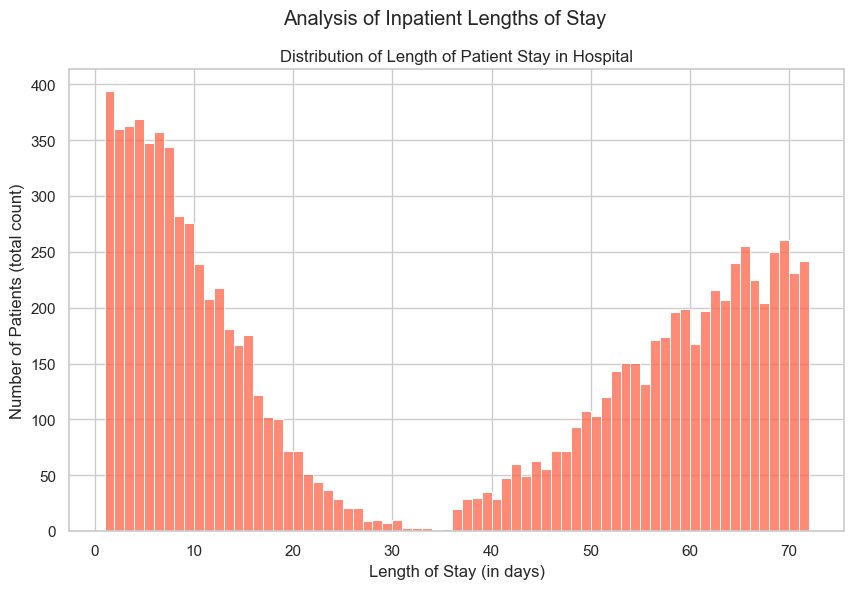

In [18]:
# Univariate visualization for the dependent variable: Initial_days
plt.figure(figsize=(10, 6)) 
plt.suptitle('Analysis of Inpatient Lengths of Stay')
sns.histplot(df['Initial_days'], color='tomato', binwidth=1)  
plt.title('Distribution of Length of Patient Stay in Hospital')
plt.xlabel('Length of Stay (in days)')
plt.ylabel('Number of Patients (total count)')

plt.show()

### Income

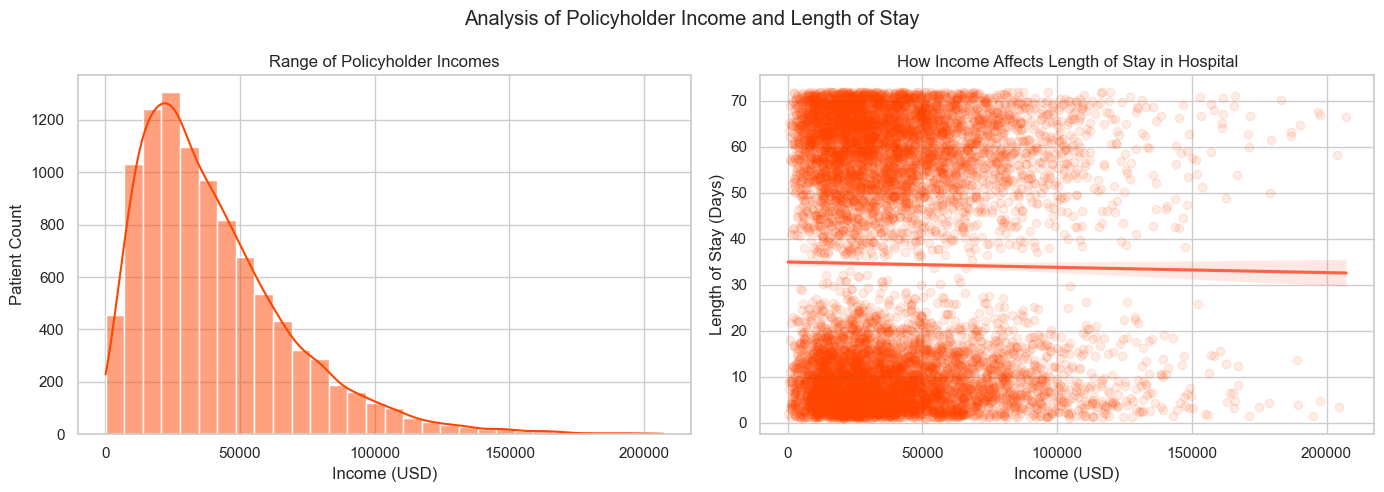

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Policyholder Income and Length of Stay")

# LEFT GRAPH: Univariate analysis of policyholder income
sns.histplot(df['Income'], bins=30, ax=ax[0], kde=True, color='orangered')
ax[0].set_title('Range of Policyholder Incomes')
ax[0].set_xlabel('Income (USD)')
ax[0].set_ylabel('Patient Count')

# RIGHT GRAPH: Bivariate analysis of policyholder income & length of stay
sns.regplot(x='Income', y='Initial_days', data=df, scatter_kws={'alpha': 1/10}, line_kws={'color':'tomato'}, ax=ax[1], color="orangered")
ax[1].set_title('How Income Affects Length of Stay in Hospital')
ax[1].set_xlabel('Income (USD)')
ax[1].set_ylabel('Length of Stay (Days)')

plt.tight_layout()
plt.show()

### Age

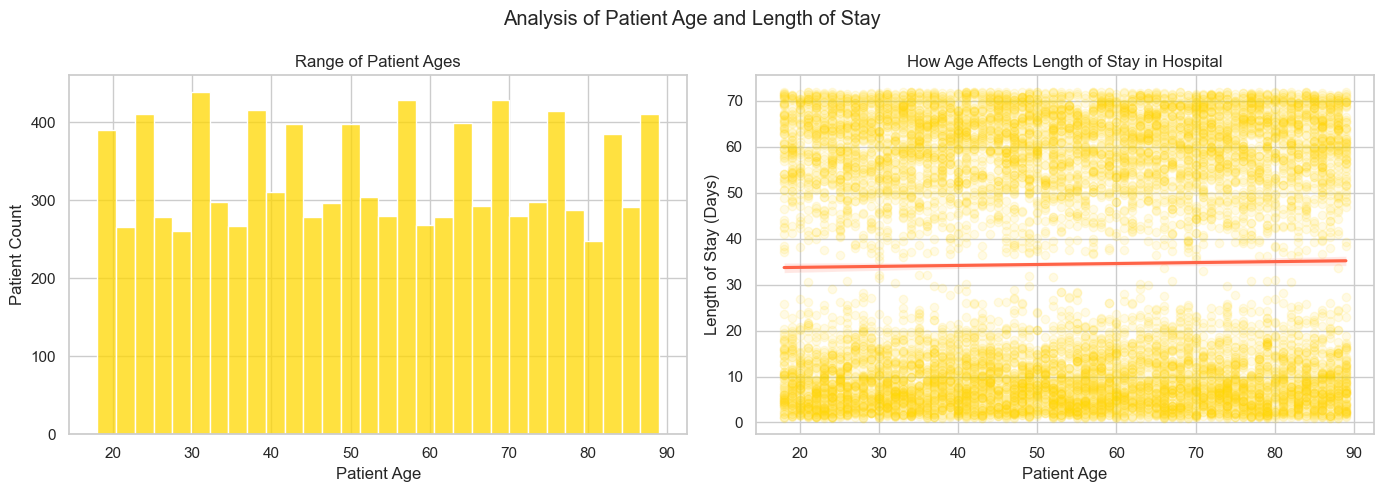

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Patient Age and Length of Stay")

# LEFT GRAPH: Univariate analysis of age 
sns.histplot(df['Age'], bins=30, ax=ax[0], color='gold')
ax[0].set_title('Range of Patient Ages')
ax[0].set_xlabel('Patient Age')
ax[0].set_ylabel('Patient Count')

# RIGHT GRAPH: Bivariate analysis of age & length of stay
sns.regplot(x='Age', y='Initial_days', data=df, scatter_kws={'alpha': 1/10}, line_kws={'color':'tomato'}, ax=ax[1], color="gold")
ax[1].set_title('How Age Affects Length of Stay in Hospital')
ax[1].set_xlabel('Patient Age')
ax[1].set_ylabel('Length of Stay (Days)')

plt.tight_layout()
plt.show()

### Children

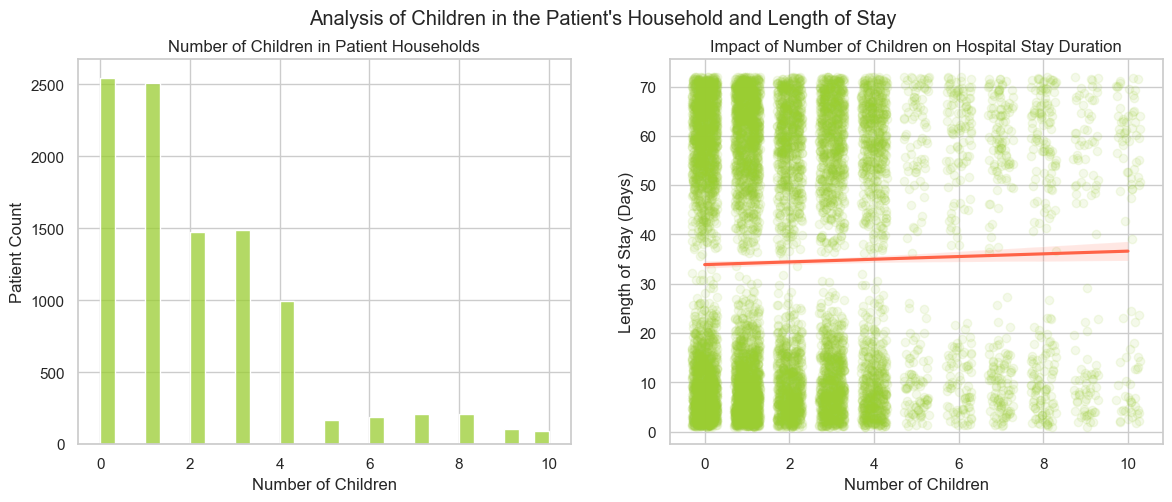

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Children in the Patient's Household and Length of Stay")

# LEFT GRAPH: Univariate analysis of number of children in the patient's household
sns.histplot(df['Children'], bins=30, ax=ax[0], color='yellowgreen')
ax[0].set_title("Number of Children in Patient Households")
ax[0].set_xlabel('Number of Children')
ax[0].set_ylabel('Patient Count')

# RIGHT GRAPH: Bivariate analysis of number of children in the patient's household & length of stay
sns.regplot(x='Children', y='Initial_days', data=df, x_jitter=0.3, scatter_kws={'alpha': 1/10}, line_kws={'color':'tomato'}, ax=ax[1], color="yellowgreen")
ax[1].set_title("Impact of Number of Children on Hospital Stay Duration")
ax[1].set_xlabel('Number of Children')
ax[1].set_ylabel('Length of Stay (Days)')

plt.show()

### TotalCharge (Average Daily Charge)

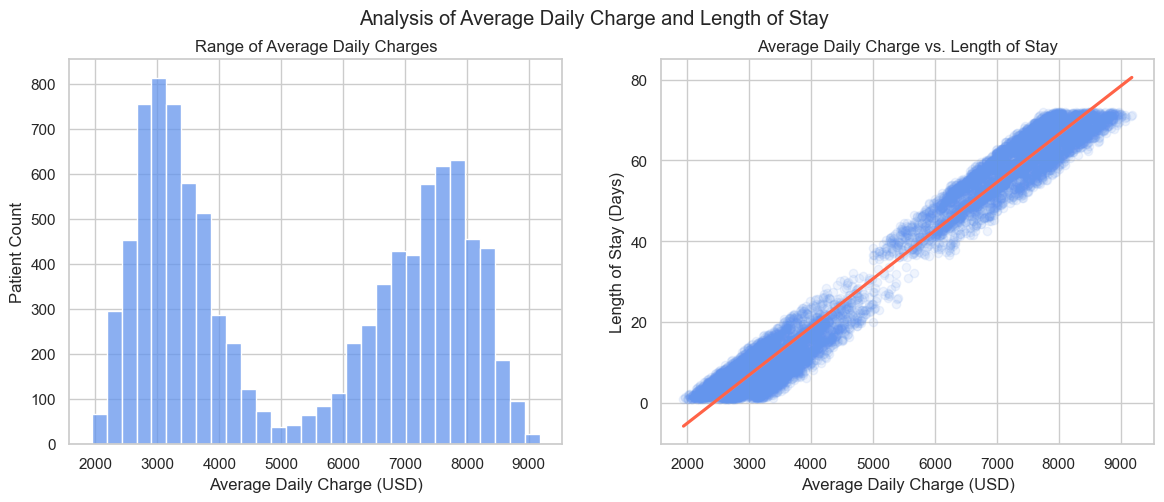

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Average Daily Charge and Length of Stay")

# LEFT GRAPH: Univariate analysis of average daily charge
sns.histplot(df['TotalCharge'], bins=30, ax=ax[0], color='cornflowerblue')
ax[0].set_title("Range of Average Daily Charges")
ax[0].set_xlabel('Average Daily Charge (USD)')
ax[0].set_ylabel('Patient Count')

# RIGHT GRAPH: Bivariate analysis of average daily charge & length of stay
sns.regplot(x='TotalCharge', y='Initial_days', data=df, x_jitter=0.3, scatter_kws={'alpha': 1/10}, line_kws={'color':'tomato'}, ax=ax[1], color="cornflowerblue")
ax[1].set_title("Average Daily Charge vs. Length of Stay")
ax[1].set_xlabel('Average Daily Charge (USD)')
ax[1].set_ylabel('Length of Stay (Days)')

plt.show()

### Gender

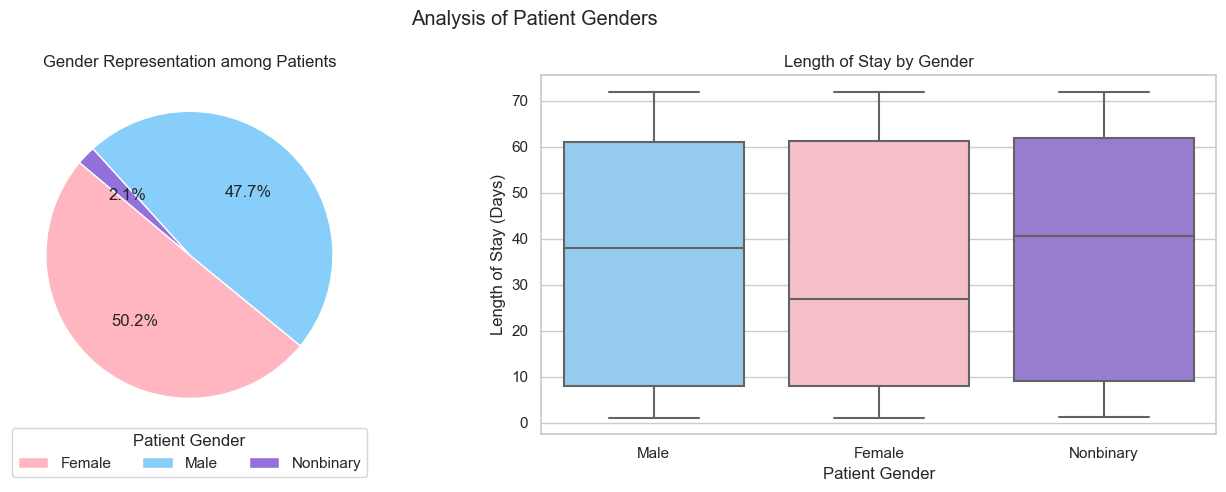

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Patient Genders")

# LEFT plot: Univariate analyis of gender
gender_counts = df['Gender'].value_counts()
slice_colors = ['lightpink', 'lightskyblue', 'mediumpurple']
ax[0].pie(gender_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Gender Representation among Patients')
ax[0].legend(gender_counts.index, title="Patient Gender", loc='center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# RIGHT plot: Bivariate analyis of gender vs. length of stay
box_colors = ['lightskyblue', 'lightpink', 'mediumpurple']
sns.boxplot(x='Gender', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
ax[1].set_title('Length of Stay by Gender')
ax[1].set_xlabel('Patient Gender')
ax[1].set_ylabel('Length of Stay (Days)')

plt.tight_layout()
plt.show()

### Complication_risk (Complication Risk Level)

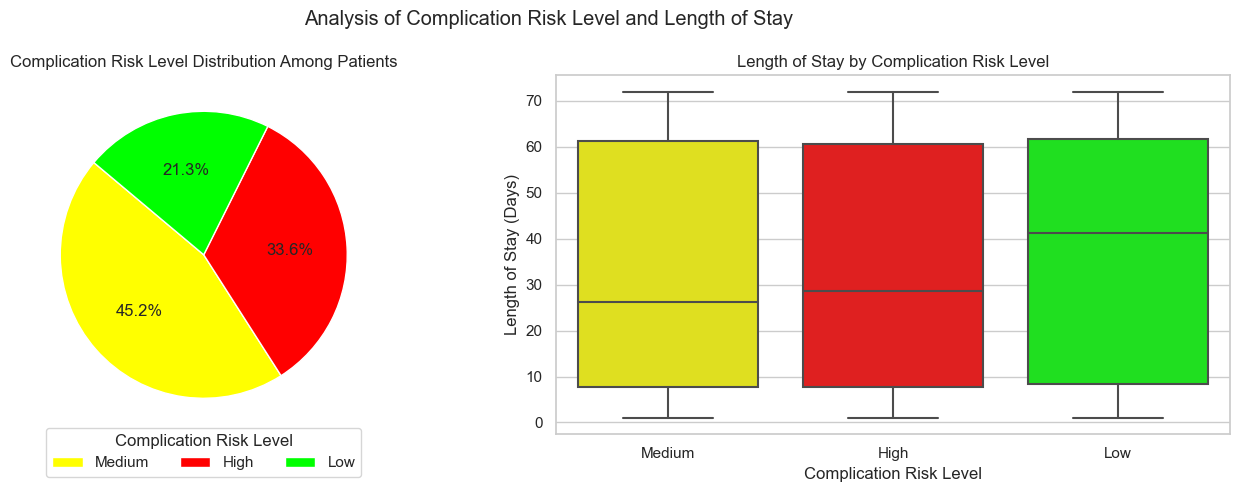

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Complication Risk Level and Length of Stay")

# LEFT plot: Univariate analysis of complication risk
risk_counts = df['Complication_risk'].value_counts()
slice_colors = ['yellow', 'red', 'lime']
ax[0].pie(risk_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Complication Risk Level Distribution Among Patients')
ax[0].legend(risk_counts.index, title="Complication Risk Level", loc='center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# RIGHT plot: Bivariate analysis of complication risk & length of stay
box_colors = ['yellow', 'red', 'lime']
sns.boxplot(x='Complication_risk', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
ax[1].set_title('Length of Stay by Complication Risk Level')
ax[1].set_xlabel('Complication Risk Level')
ax[1].set_ylabel('Length of Stay (Days)')

plt.tight_layout()
plt.show()

### Initial_admin (Admission Type)

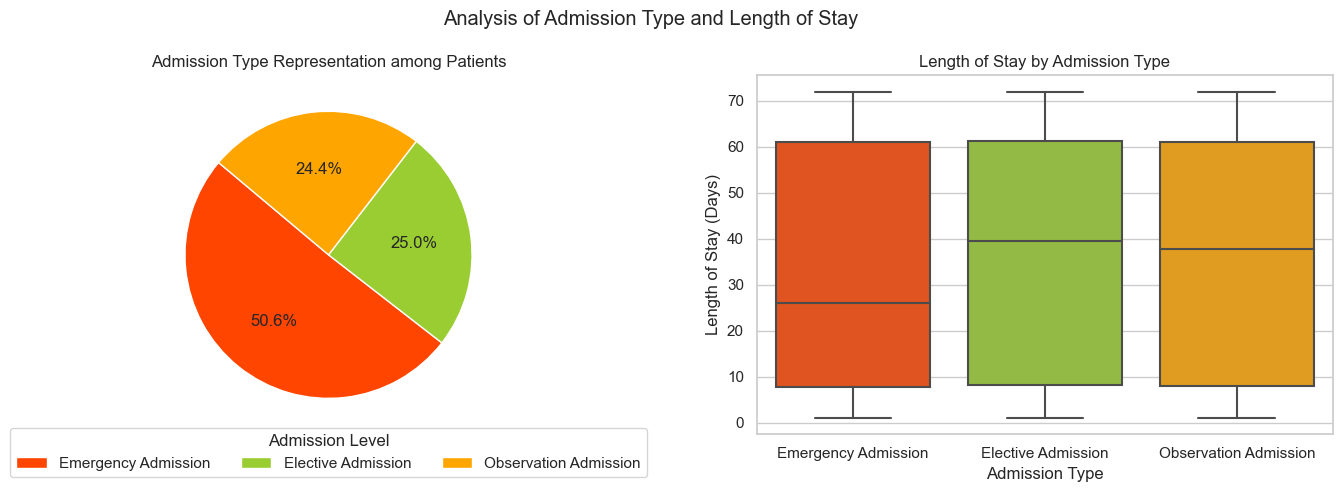

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Admission Type and Length of Stay")

# LEFT GRAPH: Univariate analysis of admission type
admission_counts = df['Initial_admin'].value_counts()
slice_colors = ['orangered', 'yellowgreen', 'orange']
ax[0].pie(admission_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Admission Type Representation among Patients')
ax[0].legend(admission_counts.index, title="Admission Level", loc='center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# RIGHT GRAPH: Bivariate analysis of admission type & length of stay
box_colors = ['orangered', 'yellowgreen', 'orange']
sns.boxplot(x='Initial_admin', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
ax[1].set_title('Length of Stay by Admission Type')
ax[1].set_xlabel('Admission Type')
ax[1].set_ylabel('Length of Stay (Days)')

plt.tight_layout()
plt.show()

### Overweight

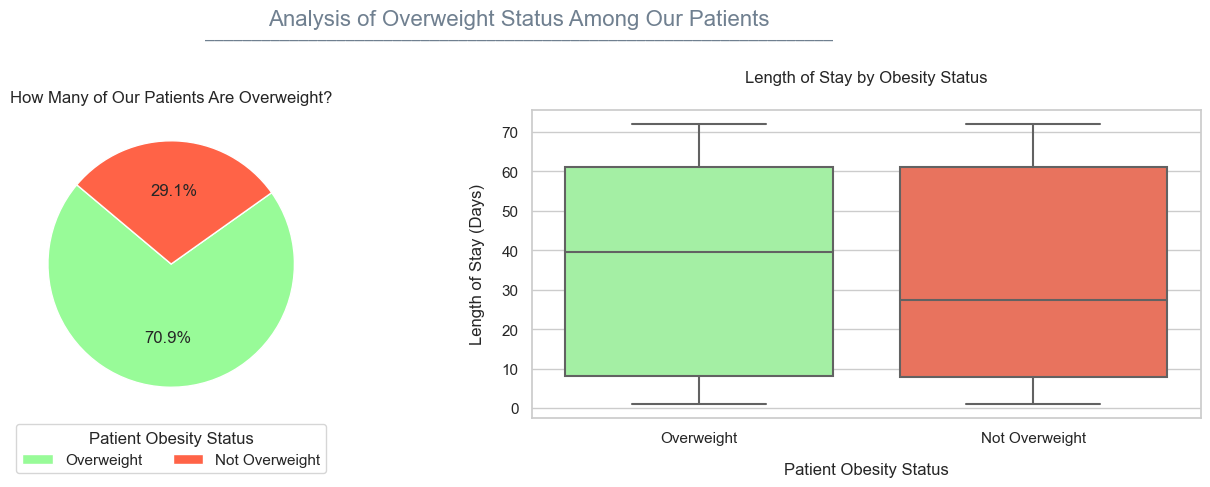

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Overweight Status Among Our Patients", fontsize=16, color='slategray')

# LEFT GRAPH: Univariate analysis of overweight status
overweight_counts = df['Overweight'].value_counts()
slice_colors = ['palegreen', 'tomato']
legend_labels = ['Overweight', 'Not Overweight']
ax[0].pie(overweight_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('How Many of Our Patients Are Overweight?')
ax[0].legend(legend_labels, title="Patient Obesity Status", loc='center', bbox_to_anchor=(0.5, -0.10), ncol=2)

# RIGHT GRAPH: Bivariate analysis of overweight status vs. length of stay
box_colors = ['palegreen', 'tomato']
sns.boxplot(x='Overweight', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
boxplot_labels = ['Overweight', 'Not Overweight']
ax[1].set_xticklabels(boxplot_labels)
ax[1].set_title('Length of Stay by Obesity Status', pad=20)
ax[1].set_xlabel('Patient Obesity Status', labelpad=12)
ax[1].set_ylabel('Length of Stay (Days)', labelpad=12)


fig.text(0.5, 0.92, '–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––', ha='center', va='center', color='slategray')


plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

### Diabetes

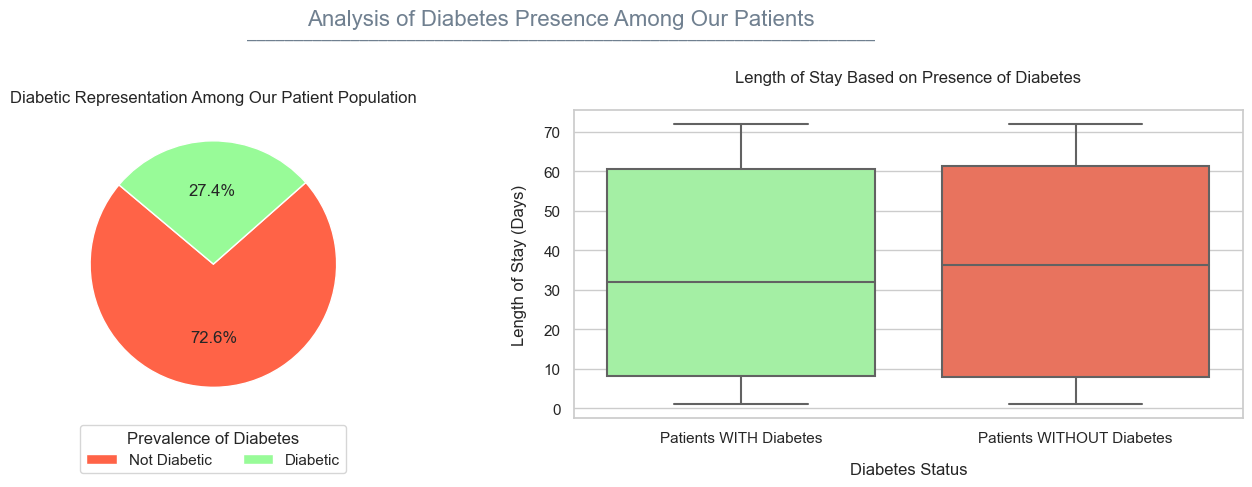

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Diabetes Presence Among Our Patients", fontsize=16, color='slategray')

# LEFT GRAPH: Univariate analysis of presence of diabetes
diabetes_counts = df['Diabetes'].value_counts()
slice_colors = ['tomato','palegreen']
legend_labels = ['Not Diabetic', 'Diabetic']
ax[0].pie(diabetes_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Diabetic Representation Among Our Patient Population')
ax[0].legend(legend_labels, title="Prevalence of Diabetes", loc='center', bbox_to_anchor=(0.5, -0.10), ncol=2)

# RIGHT GRAPH: Bivariate analysis of presence of diabetes vs. length of stay
box_colors = ['palegreen','tomato']
sns.boxplot(x='Diabetes', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
boxplot_labels = ['Patients WITH Diabetes', 'Patients WITHOUT Diabetes']
ax[1].set_xticklabels(boxplot_labels)
ax[1].set_title('Length of Stay Based on Presence of Diabetes', pad=20)
ax[1].set_xlabel('Diabetes Status', labelpad=12)
ax[1].set_ylabel('Length of Stay (Days)', labelpad=12)

fig.text(0.5, 0.92, '–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––', ha='center', va='center', color='slategray')


plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

### HighBlood (High Blood Pressure)

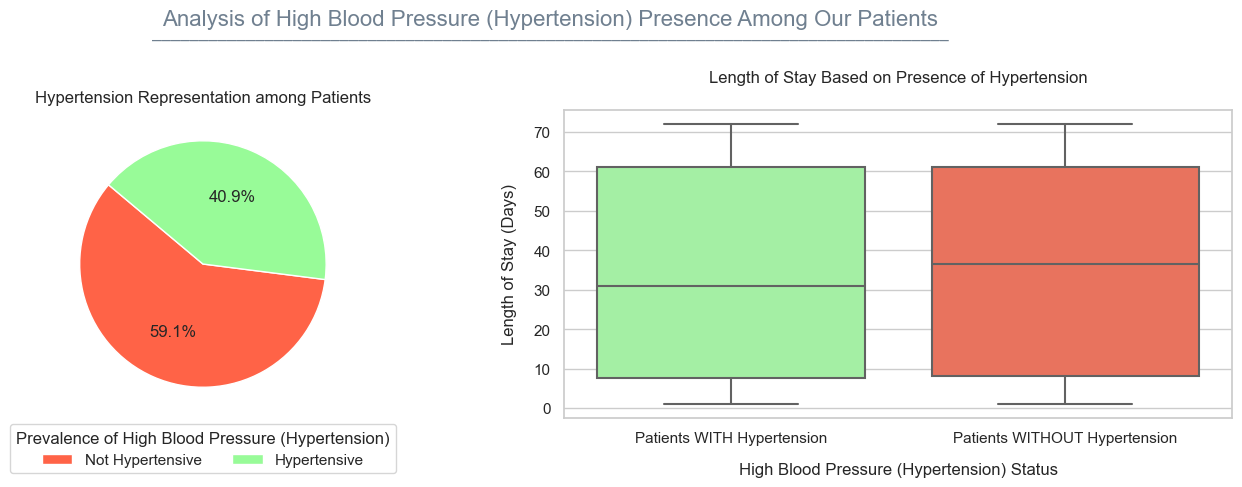

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of High Blood Pressure (Hypertension) Presence Among Our Patients", fontsize=16, color='slategray')

# LEFT GRAPH: Univariate analysis of presence of high blood pressure
high_bp_counts = df['HighBlood'].value_counts()
slice_colors = ['tomato','palegreen']
legend_labels = ['Not Hypertensive', 'Hypertensive']
ax[0].pie(high_bp_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Hypertension Representation among Patients')
ax[0].legend(legend_labels, title="Prevalence of High Blood Pressure (Hypertension)", loc='center', bbox_to_anchor=(0.5, -0.10), ncol=2)

# RIGHT GRAPH: Bivariate analysis of presence of high blood pressure vs. length of stay
box_colors = ['palegreen','tomato']
sns.boxplot(x='HighBlood', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
boxplot_labels = ['Patients WITH Hypertension', 'Patients WITHOUT Hypertension']
ax[1].set_xticklabels(boxplot_labels)
ax[1].set_title('Length of Stay Based on Presence of Hypertension', pad=20)
ax[1].set_xlabel('High Blood Pressure (Hypertension) Status', labelpad=12)
ax[1].set_ylabel('Length of Stay (Days)', labelpad=12)

fig.text(0.5, 0.92, '–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––', ha='center', va='center', color='slategray')


plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

###  BackPain 

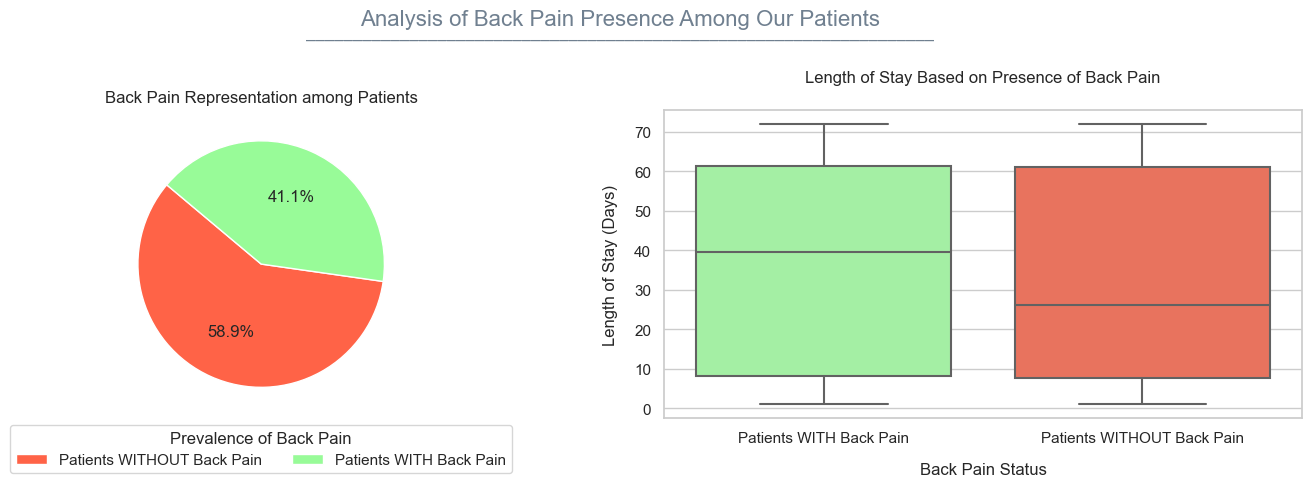

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Back Pain Presence Among Our Patients", fontsize=16, color='slategray')

# LEFT GRAPH: Univariate analysis of presence of back pain
bp_counts = df['BackPain'].value_counts()
slice_colors = ['tomato','palegreen']
legend_labels = ['Patients WITHOUT Back Pain', 'Patients WITH Back Pain']
ax[0].pie(bp_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Back Pain Representation among Patients')
ax[0].legend(legend_labels, title="Prevalence of Back Pain", loc='center', bbox_to_anchor=(0.5, -0.10), ncol=2)

# RIGHT GRAPH: Bivariate analysis of presence of back pain vs. length of stay
box_colors = ['palegreen','tomato']
sns.boxplot(x='BackPain', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
boxplot_labels = ['Patients WITH Back Pain', 'Patients WITHOUT Back Pain']
ax[1].set_xticklabels(boxplot_labels)
ax[1].set_title('Length of Stay Based on Presence of Back Pain', pad=20)
ax[1].set_xlabel('Back Pain Status', labelpad=12)  
ax[1].set_ylabel('Length of Stay (Days)', labelpad=12)


fig.text(0.5, 0.92, '–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––', ha='center', va='center', color='slategray')


plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

### Asthma

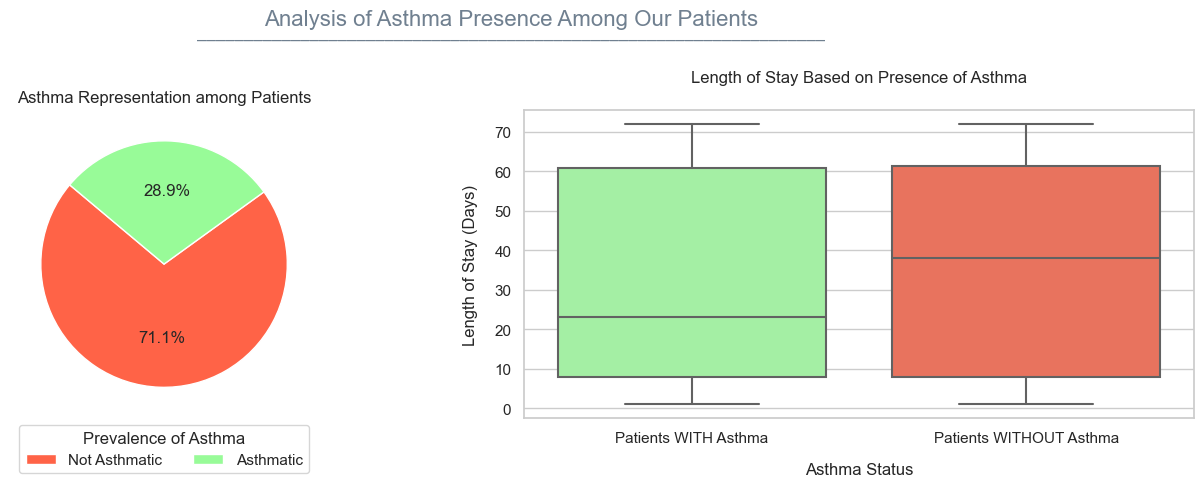

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Asthma Presence Among Our Patients", fontsize=16, color='slategray')

# LEFT GRAPH: Univariate analysis of presence of asthma
asthma_counts = df['Asthma'].value_counts()
slice_colors = ['tomato','palegreen']
legend_labels = ['Not Asthmatic', 'Asthmatic']
ax[0].pie(asthma_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Asthma Representation among Patients')
ax[0].legend(legend_labels, title="Prevalence of Asthma", loc='center', bbox_to_anchor=(0.5, -0.10), ncol=2)

# RIGHT GRAPH: Bivariate analysis of presence of asthma vs. length of stay
box_colors = ['palegreen','tomato']
sns.boxplot(x='Asthma', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
boxplot_labels = ['Patients WITH Asthma', 'Patients WITHOUT Asthma']
ax[1].set_xticklabels(boxplot_labels)
ax[1].set_title('Length of Stay Based on Presence of Asthma', pad=20)
ax[1].set_xlabel('Asthma Status', labelpad=12)  
ax[1].set_ylabel('Length of Stay (Days)', labelpad=12)

fig.text(0.5, 0.92, '–––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––', ha='center', va='center', color='slategray')

plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

### Stroke

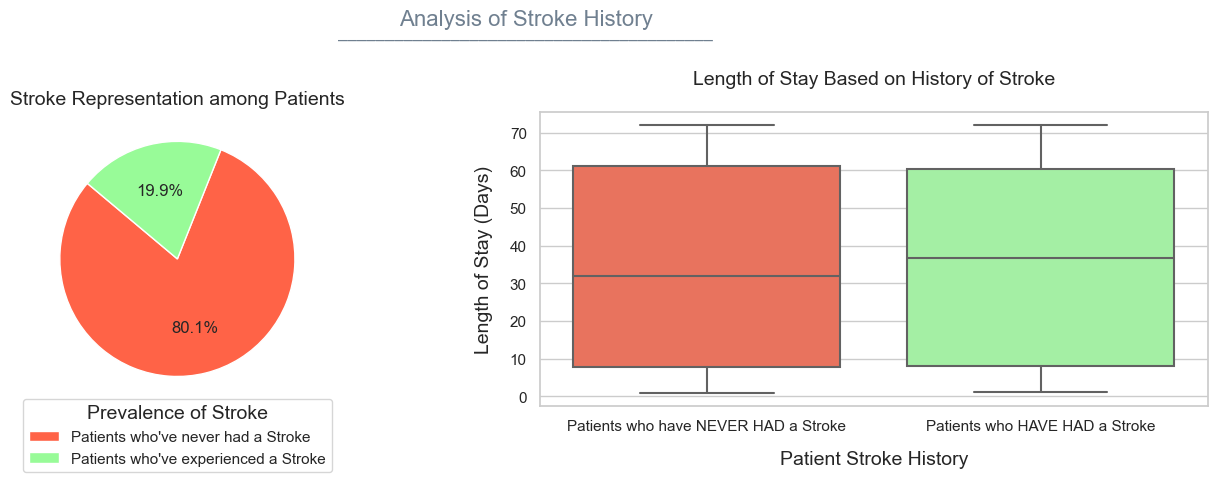

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Analysis of Stroke History", fontsize=16, color='slategray')

# LEFT GRAPH: Univariate analysis of presence of history of stroke
stroke_counts = df['Stroke'].value_counts()
slice_colors = ['tomato', 'palegreen']
legend_labels = ["Patients who've never had a Stroke", "Patients who've experienced a Stroke"]
ax[0].pie(stroke_counts, autopct='%1.1f%%', startangle=140, colors=slice_colors)
ax[0].set_title('Stroke Representation among Patients', fontsize=14)
ax[0].legend(legend_labels, title="Prevalence of Stroke", loc='center', bbox_to_anchor=(0.5, -0.10), ncol=1, title_fontsize='14')

# RIGHT GRAPH: Bivariate analysis of presence of history of stroke vs. length of stay
box_colors = ['tomato', 'palegreen']
sns.boxplot(x='Stroke', y='Initial_days', data=df, ax=ax[1], palette=box_colors)
boxplot_labels = ['Patients who have NEVER HAD a Stroke', 'Patients who HAVE HAD a Stroke']
ax[1].set_xticklabels(boxplot_labels)
ax[1].set_title('Length of Stay Based on History of Stroke', fontsize=14, pad=20)
ax[1].set_xlabel('Patient Stroke History', labelpad=12, fontsize=14)
ax[1].set_ylabel('Length of Stay (Days)', labelpad=12, fontsize=14)

fig.text(0.5, 0.92, '––––––––––––––––––––––––––––––––––––––––', ha='center', va='center', color='slategray')


plt.tight_layout(rect=[0, 0, 1, 0.97]) 
plt.show()

### Summary
The univariate visualizations provide insights into the distribution of both the dependent and independent variables in our dataset:
- **Initial_days (Length of Stay)**: The data shows a bimodal distribution with two distinct peaks. The average value (mean) falls close to a valley between these peaks. 
- **Income**: Income distribution is right-skewed, similar to length of stay, suggesting that lower incomes (less than 150k) are more common among our patient population
- **Age**: Our graph shows a relatively uniform distribution of patients across the different age groups, with ever-so-slight decreases in frequency as age increases (which is to be expected with the average human lifespan)
- **TotalCharge**: As with the length of stay, this also shows a bimodal distribution with two distinct peaks with the average value falling close to a valley between these peaks. 
- **Children**: Most patients have fewer than 3 children in their household, with a decreasing frequency as the number of children increases
- **Complication_risk**: We see a majority of patients are in the medium risk category, followed by high then low.
- **Inital_admin:** About half of our patients are admitted for emergency, followed by a relatively even split between observation and elective admissions. 
- **Overweight**: A significant (almost 71%) portion of our patient population is overweight.
- **Diabetes**: A majority of our patients aren't diabetic.
- **HighBlood**: While there is certainly a prevalence of high blood pressure among our population, it's pretty evenly split - with more patients (~59%) not having hypertension. 
- **BackPain**: Most of our patients don't experience back pain.
- **Asthma**: Not very many of our patients are asthmatic with only 28.9% having asthma.
- **Stroke**: An even smaller number of our patients have a history of stroke (80.1%). 

Our bivariate visualizations also reveal some interesting insights into the relationship between independent variables and length of stay:

- **Income vs. Length of Stay:** The scatter plot shows a distribution suggesting no clear or strong correlation between a policyholder's income and the length of hospital stay. The length of stay data is spread across all income levels without a discernable pattern and a relatively even distribution of stay lengths across the income spectrum is visible. 
- **Age vs. Length of Stay:** There seems to be no strong or consistent correlation between patient age and length of hospital stay, as our data points are widely dispersed across all ages for varying lengths of stay. The plot shows a dense cloud of points at the lower lengths of stay across all ages, indicating that most hospital stays are short, regardless of the patient's age. 
- **TotalCharge vs. Length of Stay:** A clear positive linear trend is visible. As daily charges increase, so does the length of stay. The red line represents a linear fit, showing that higher daily charges are generally associated with longer hospital stays. The spread around the line suggests that while there is a strong overall trend, there is some variability, indicating that not all patients with high charges have long stays and vice versa.
- **Children vs. Length of Stay:** There's no evident correlation between the number of children in a patient's household and the length of their hospital stay, as the the lengths are broadly dispersed across different numbers of children without any visible trend.
- **Gender vs. Length of Stay:** The median length of stay is slightly higher for male and nonbinary patients, but the range and interquartile range of stays are similar across all 3 genders suggesting it may not be strong predictor of the length of hospital stay.
- **Complication Risk Level vs. Length of Stay:** The median length of stay is slightly higher for patients with medium complication risk compared to those with high and low risks, but the range and interquartile range of stays are similar across all 3 risk levels suggesting complication risk level may not be strong predictor of the length of hospital stay.
- **Admission Type vs. Length of Stay:** The median length of stay is somewhat similar for all 3 admission types, with emergency admissions showing slightly higher median and variability. However, all types show a broad range of stays, suggesting admission type alone may not be a major factor for the length of stay. 
- **Overweight vs. Length of Stay:** Both non-overweight and overweight groups have a similar median length of stay in the hospital, with a slightly higher median for the overweight group. The distribution and range of stays are quite similar across both groups, though, indicating that being overweight may not signficantly affect length of stay.
- **Diabetes vs. Length of Stay:** Both diabetic and non-diabetic groups have a similar median length of stay in the hospital, with a slightly higher median for the non-diabetic group. The distribution and range of stays are quite similar across both groups, though, indicating that having diabetes may not signficantly affect length of stay.
- **HighBlood vs. Length of Stay:** Both hypertensive and non-hypertensive groups have a similar median length of stay in the hospital, with a slightly higher median for the non-hypertensive group. The distribution and range of stays are quite similar across both groups, though, indicating that having high blood pressure may not signficantly affect length of stay.
- **BackPain vs. Length of Stay:** Both groups with and without back pain have a similar median length of stay in the hospital, with a slightly higher median for those with back pain. The distribution and range of stays are quite similar across both groups, though, indicating that back pain may not signficantly affect length of stay.
- **Asthma vs. Length of Stay:** Both groups with and without asthma have a similar median length of stay in the hospital, with a slightly higher median for those without asthma. The distribution and range of stays are quite similar across both groups, though, indicating that asthma may not signficantly affect length of stay.
- **Stroke vs. Length of Stay:** We see that a majority of our patients have never had a stroke. Interestingly, though, when we look at the bivariate visualization, we can see that those few that have had previously had a stroke are more apt to stay longer in our hospital. 

<a id="c4"></a>
## C4. Data Transformation Goals & Steps

### Goals
Our primary objective is to preprocess our data for regression analysis. As noted in section [C1. Data Cleaning Goals & Steps](#c1), we have several categorical variables relevant to our research question that we need to encode into a numerical format suitable for our regression model. Additionally, we'll make minor adjustments, such as subsetting the dataset to include only relevant variables and standardizing column names, to further enhance data quality and compatibility.

### Steps

#### Data Type Handling

**Numeric Variable Precision:** <br>
Convert income data from decimal format to whole numbers by removing fractional parts.

In [32]:
# Cast Income column data type from float to integer
df["Income"] = df["Income"].astype(int)

Round down TotalCharge to two decimal places to better reflect dollar amounts.

In [33]:
# Reduce column precision from 6 to 2 decimal places to better reflect USD pricing
df["TotalCharge"] = df.TotalCharge.round(2)

**Categorical Variable Conversion:** <br>
Convert Gender, Complication_risk, and Initial_admin to categorical data types to accurately represent their respective values.

In [34]:
# Cast column data types from string to category
df["Gender"] = df["Gender"].astype("category")
df["Complication_risk"] = df["Complication_risk"].astype("category")
df["Initial_admin"] = df["Initial_admin"].astype("category")

Our dataset contains several categorical variables, which are not directly compatible with regression models that primarily work with numerical data. 

To handle categorical variables in our linear regression model, we'll employ one-hot encoding using the get_dummies() function. This process creates separate binary columns for each category, ensuring that the model can understand and process these categorical features. To prevent multicollinearity, we'll drop the first category in each categorical variable using the drop_first=True parameter. This category will serve as our baseline, and the coefficients of the remaining columns will represent the difference in the outcome variable relative to this baseline.

For instance, when applied to the complication_risk_level feature, one-hot encoding will generate two new binary columns: complication_risk_level_Low and complication_risk_level_Medium. The High category is dropped as the baseline. The interpretation of the coefficients for these new columns will be relative to the High category:

- complication_risk_level_Low = 1: Indicates a complication risk level of "Low" compared to "High"
- complication_risk_level_Medium = 1: Indicates a complication risk level of "Medium" compared to "High"

In [35]:
# Create dummy variables, dropping the first column to avoid multicollinearity
df_gender = pd.get_dummies(data=df["Gender"], drop_first=True)
df_admission_type = pd.get_dummies(data=df["Initial_admin"], drop_first=True)
df_complication_risk_level = pd.get_dummies(data=df["Complication_risk"], drop_first=True)

**Boolean Variable Conversion:** <br>
Convert Overweight, Diabetes, HighBlood, BackPain, Asthma, and Stroke to boolean values (1 for "Yes" and 0 for "No") using a conversion dictionary. This will ensure compatibility with the numerical requirements of the regression model.

In [36]:
# Define the boolean conversion dictionary
boolean_conversion = {"Yes" : 1, "No" : 0}

# Map string objects to respective boolean values, changing data type to int
df["Overweight"] = df["Overweight"].map(boolean_conversion)
df["Diabetes"] = df["Diabetes"].map(boolean_conversion)
df["HighBlood"] = df["HighBlood"].map(boolean_conversion)
df["BackPain"] = df["BackPain"].map(boolean_conversion)
df["Asthma"] = df["Asthma"].map(boolean_conversion)
df["Stroke"] = df["Stroke"].map(boolean_conversion)

#### Subset the Dataset

To focus on the relevant variables for our model, we'll create a new dataset called df_subset that includes only the columns we plan to use as features. This will help streamline our analysis and improve computational efficiency.

In [37]:
# Subset the dataset, selecting only the columns relevant to our research question
df_subset = df[["Initial_days", "Age", "Income", "Children", "Overweight", "Diabetes", "BackPain", "Asthma", "HighBlood", "Stroke", "TotalCharge"]]

#### Update Column Names

Rename column labels to provide more descriptive and meaningful names that accurately reflect the data they contain. This will enhance data clarity and prevent misunderstandings when working with the dataset. Ensure that the new labels are consistent in style and format.

In [38]:
# Update column labels for better understanding and consistency
updated_columns = ["length_of_stay", "age", "income", "children_in_household", "overweight", "diabetes", "back_pain", "asthma", "high_bp", "stroke", "daily_charge"]
df_subset.set_axis(updated_columns, axis=1, inplace=True)

/var/folders/lq/6c9hklwx5hbbg3mt9flq5rmr0000gn/T/ipykernel_21048/1815406732.py:3: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  df_subset.set_axis(updated_columns, axis=1, inplace=True)


#### Insert Dummies 

After constructing our new dataframe, we can use the insert function to strategically place our newly generated dummy variables within the desired columns, ensuring they align with the existing data structure and facilitate subsequent analysis.

In [39]:
# Insert dummy variables for the 'complication_risk_level' categorical variable
df_subset.insert(4, "complication_risk_level_medium", df_complication_risk_level.Medium)
df_subset.insert(4, "complication_risk_level_low", df_complication_risk_level.Low)

# Insert dummy variables for the 'admission_type' categorical variable
df_subset.insert(4, "admission_type_emergency", df_admission_type["Emergency Admission"])
df_subset.insert(4, "admission_type_observation", df_admission_type["Observation Admission"])

# Insert dummy variables for the 'gender' categorical variable
df_subset.insert(3, "gender_nonbinary", df_gender.Male)
df_subset.insert(3, "gender_male", df_gender.Male)

In [40]:
# Preview the resulting dataframe
df_subset

,length_of_stay,age,income,gender_male,gender_nonbinary,children_in_household,admission_type_observation,admission_type_emergency,complication_risk_level_low,complication_risk_level_medium,overweight,diabetes,back_pain,asthma,high_bp,stroke,daily_charge
0,10.585770,53,86575,1,1,1,0,1,0,1,0,1,1,1,1,0,3726.70
1,15.129562,51,46805,0,0,3,0,1,0,0,1,0,0,0,1,0,4193.19
2,4.772177,53,14370,0,0,3,0,0,0,1,1,1,0,0,1,0,2434.23
3,1.714879,78,39741,1,1,0,0,0,0,1,0,0,0,1,0,1,2127.83
4,1.254807,22,1209,0,0,1,0,0,1,0,0,0,0,0,0,0,2113.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,51.561220,25,45967,1,1,2,0,1,0,1,0,0,0,0,1,0,6850.94
9996,68.668240,87,14983,1,1,4,0,0,0,1,1,1,0,1,1,0,7741.69
9997,70.154180,45,65917,0,0,3,0,0,0,0,1,0,0,0,1,0,8276.48
9998,63.356900,43,29702,1,1,3,0,1,0,1,1,0,1,0,0,0,7644.48


In [41]:
# Check data types have been updated properly 
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   length_of_stay                  10000 non-null  float64
 1   age                             10000 non-null  int64  
 2   income                          10000 non-null  int64  
 3   gender_male                     10000 non-null  uint8  
 4   gender_nonbinary                10000 non-null  uint8  
 5   children_in_household           10000 non-null  int64  
 6   admission_type_observation      10000 non-null  uint8  
 7   admission_type_emergency        10000 non-null  uint8  
 8   complication_risk_level_low     10000 non-null  uint8  
 9   complication_risk_level_medium  10000 non-null  uint8  
 10  overweight                      10000 non-null  int64  
 11  diabetes                        10000 non-null  int64  
 12  back_pain                       1

<a id="c5"></a>
## C5. Prepared Data Set

See prepared data set attached via file ‘task1_ transformed_medical_clean.csv’

In [42]:
# Save the transformed dataset as a CSV file
df_subset.to_csv('task1_transformed_medical_clean.csv', index=False)

<a id="4"></a>
# Part IV: Model Comparison & Analysis

<a id="d1"></a>
## D1. Initial Multiple Linear Regression Model

In [43]:
# Construct initial linear regression model 

# Define dependent variable (y)
y = df_subset['length_of_stay']

# Define independent variables (X)
X1 = df_subset[['age', 'income', 'daily_charge', 'children_in_household', 
                'overweight', 'diabetes', 'back_pain', 'high_bp', 'stroke', 
                'gender_male', 'gender_nonbinary',
                'complication_risk_level_low', 'complication_risk_level_medium', 
                'admission_type_emergency', 'admission_type_observation']] 

# Add a constant (intercept) to the model
X = sm.add_constant(X1) 

# Fit the linear regression model
initial_model = sm.OLS(y, X).fit() 

# Display summary of initial model
print(initial_model.summary())

                            OLS Regression Results                            
Dep. Variable:         length_of_stay   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.120e+05
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        14:05:06   Log-Likelihood:                -14000.
No. Observations:               10000   AIC:                         2.803e+04
Df Residuals:                    9985   BIC:                         2.814e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

### Summary
#### Model Summary
- The **R-squared** value is 0.999, indicating that the model explains 99.9% of the variability in the length of stay. This is a very high level of explained variance, but it might indicate overfitting.
- Our **Adjusted R-Squared** value is 0.999, very similar to the R-squared, suggesting that the model’s performance remains strong even when accounting for the number of predictors.
- The **F-statistic** is 5.120e+05, with a p-value of 0.000, suggesting that the overall model is statistically significant.

### Coefficients 
#### Signifiant Predictors 
- **Daily Charge**: This variable has a positive coefficient (0.0122) and appears to be highly significant (p = 0.000), meaning an increase in daily charges may be associated with a longer length of stay.
- **Diabetes**: Has a negative coefficient (-0.9351) and highly significant (p = 0.000), suggesting that individuals with diabetes have shorter stays.
- **Back Pain**: Has a negative coefficient (-1.0423) and highly significant (p = 0.000), indicating a shorter stay for patients with back pain.
- **High Blood Pressure**: Has a negative coefficient (-1.3833), highly significant (p = 0.000), meaning patients with high blood pressure stay for a shorter period.
- **Complication Risk Level (Low and Medium)**: Both have large positive coefficients (Low = 5.0216, Medium = 5.0137), and both are highly significant (p = 0.000). Higher complication risk levels are strongly associated with longer stays.
- **Admission Type (Emergency)**: Strong negative coefficient (-6.2572), highly significant (p = 0.000), indicating that emergency admissions tend to result in shorter stays.


The model explains most of the variance in the dependent variable (length of stay), and several variables such as daily charge, diabetes, back pain, complication risk levels, and emergency admissions have a significant impact on the length of stay. However, the high R-squared and condition number (2.99e+20, which is quite large) suggest possible overfitting or multicollinearity in the model.

<a id="d2"></a>
## D2. Feature Selection Procedure

Our initial regression model encountered issues with multicollinearity and a possibility of overfitting. 

To address these problems, we'll employ a two-step feature selection process:

### Step 1. Multicollinearity Removal (VIF Analysis) 
To mitigate the adverse effects of multicollinearity, we'll use the Variance Inflation Factor (VIF) to identify and eliminate features that exhibit high correlations with other predictors. VIF measures the extent to which the variance of a regression coefficient is inflated due to multicollinearity. As noted by Bhandari (2024), removing variables with high VIF values can effectively reduce multicollinearity, leading to improved model accuracy and stability. For this procedure, we'll consider a VIF threshold of 5 as indicative of problematic multicollinearity and remove any features that exceed this value.

In [44]:
# Analyze Variance Inflation Factors (VIF) to determine if any variables should be removed due to strong correlations

# Function to calculate VIF for each variable
def calculate_vif(X):
    vif = pd.DataFrame() # create dataframe to store VIF results
    vif["feature"] = X.columns # features in X
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])] # use the vif function to calc VIF for ea column in X
    return vif

# Define the features
features = ['age', 'income', 'daily_charge', 'children_in_household', 
            'overweight', 'diabetes', 'back_pain', 'high_bp', 'stroke', 
            'gender_male', 'gender_nonbinary',
            'complication_risk_level_low', 'complication_risk_level_medium', 
            'admission_type_emergency', 'admission_type_observation']

# Subset the dataset
X1 = df_subset[features]

# Set a threshold for VIF
vif_threshold = 5

# Remove variables with high VIF
while True:
    vif_scores = calculate_vif(X1)
    
    # Get the max VIF value
    max_vif = vif_scores['VIF'].max()  
    
    # IF the max VIF is above the threshold...
    if max_vif > vif_threshold:  
        # Get the feature with the highest VIF
        feature_to_remove = vif_scores.sort_values("VIF", ascending=False).iloc[0]["feature"]
        # Display what features we're removing with their VIF 
        print(f"REMOVING VARIABLE: {feature_to_remove} with VIF: {max_vif}")
        # Drop the feature with the highest VIF from the dataset
        X1 = X1.drop(columns=[feature_to_remove])
    
    # ELSE if no VIF is above the threshold, break the loop
    else:
        break

# Display result
final_vif_scores = calculate_vif(X1)
print(f"\n {final_vif_scores}")

REMOVING VARIABLE: gender_male with VIF: inf
REMOVING VARIABLE: age with VIF: 5.804877575052273


/Users/hannahbergman/anaconda3/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


REMOVING VARIABLE: daily_charge with VIF: 5.013428053520664

                            feature       VIF
0                           income  2.576529
1            children_in_household  1.813255
2                       overweight  2.853435
3                         diabetes  1.338727
4                        back_pain  1.623719
5                          high_bp  1.621075
6                           stroke  1.227776
7                 gender_nonbinary  1.776983
8      complication_risk_level_low  1.508933
9   complication_risk_level_medium  2.088401
10        admission_type_emergency  2.441649
11      admission_type_observation  1.721840


### Step 2. Feature Significance Assessment (Backward Elimination)
To futher streamline our model and enhance its predictive power, we'll use backward elimination. This iterative process involves removing features that are statistical insignificant in predicting the length of stay. Significance will be assessed using p-values derived from our Ordinary Least Squares (OLS) regression models. Features with p-values exceeding 0.05 will be deemed non-significant and discarded (Srinidhi, 2019). By retaining only statistically significant features, we can ensure that the model includes only those variables that contribute meaningfully to explaining the dependent variable. Within this step, we'll also normalize the independent variables using MinMaxScaler. This will ensure that all features are on a comparable scale, preventing features with larger magnitudes from dominating the model (Brownlee, 2020).

In [45]:
# Define backward elimination function with step summaries
def backward_elimination(independent_variables, dependent_variable, significance_level=0.05):
    
    # Set features list (all independent var names from df)
    features = independent_variables.columns.tolist()
    step = 1
    
    while len(features) > 0:
        # Add a constant to the features
        features_with_constant = sm.add_constant(independent_variables[features])
        
        # Fit the model and get p-values
        elimination_model = sm.OLS(dependent_variable, features_with_constant).fit()
        p_values = elimination_model.pvalues[1:]  # Exclude intercept
        
        # Print a summary of the current step
        print(f"\n STEP {step}: OLS SUMMARY #{step}")
        print(elimination_model.summary()) 
        
        # Find the max p-value
        max_p_value = p_values.max()
        
        # Display the retained features and their corresponding p-values
        print(f"\nRETAINED VARIABLES + P-VALUES:\n{p_values}\n")
        
        # Check if the max p-value is greater than the significance level
        if max_p_value >= significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"REMOVED VARIABLE:\n{excluded_feature} (p-value: {max_p_value} exceeded 0.05 threshold)\n")
            print(f"--------------------------------------------------------------------------------------------------")
        else:
            print("No features were removed; all p-values are statistically significant at the 0.05 level\n")
            break
        
        step += 1
    
    # Display the final selected features after backward elimination
    print(f"--------------------------------------------------------------------------------------------------")
    print(f"\nVARIABLES TO BE RETAINED IN THE FINAL MODEL:\n{features}")
    return features

# Normalize the independent variables (excluding the dependent variable)
independent_variables = df_subset.drop('length_of_stay', axis=1)  # Drop dependent variable column
normalized_df = pd.DataFrame(preprocessing.MinMaxScaler().fit_transform(independent_variables), columns=independent_variables.columns)

# Perform backward elimination on the normalized dataset
reduced_features = backward_elimination(normalized_df, df_subset['length_of_stay'])


 STEP 1: OLS SUMMARY #1
                            OLS Regression Results                            
Dep. Variable:         length_of_stay   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.778e+05
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        14:05:07   Log-Likelihood:                -14000.
No. Observations:               10000   AIC:                         2.803e+04
Df Residuals:                    9984   BIC:                         2.815e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------


 STEP 5: OLS SUMMARY #5
                            OLS Regression Results                            
Dep. Variable:         length_of_stay   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 5.974e+05
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        14:05:07   Log-Likelihood:                -14000.
No. Observations:               10000   AIC:                         2.803e+04
Df Residuals:                    9987   BIC:                         2.812e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

Through this feature selection process, our goal is to create a more robust and interpretable regression model that accurately predicts length of stay based on a set of independent, statistically significant features. 

The features that will be retained in our reduced model include:  
- admission_type_emergency
- complication_risk_level_low
- complication_risk_level_medium
- diabetes
- back_pain
- high_bp
- stroke
- daily_charge

These features will be removed because their VIF scores were greater than 5, indicating problematic multicollinearity:
- gender_male (VIF: inf)
- age (VIF: 5.804877575052273)

These features were removed because their p-values were greater than 0.05, indicating they're not statisitcally signficant: 
- asthma (p-value: 0.983271826382621)
- children_in_household (p-value: 0.9431541432806572)
- gender_nonbinary (p-value: 0.9347728687763701)
- gender_male (p-value: 0.9347728687778278)
- age (p-value: 0.6375195817950045)
- income (p-value: 0.3807302601110334)
- overweight (p-value: 0.3087504103254193)
- admission_type_observation (p-value: 0.22819662878551963)

<a id="d3"></a>
## D3. Reduced Linear Regression Model

*** _Please see above, [D2. Feature Selection Procedure](#d2), for the output of the feature selection process that led to this reduced model._ *** 

In [46]:
# Construct reduced linear regression model 

# Extract the reduced dataset with the selected features
reduced_X1 = normalized_df[reduced_features]

# Add a constant (intercept) to the model
reduced_X = sm.add_constant(reduced_X1)

# Fit the linear regression model
reduced_model = sm.OLS(df_subset['length_of_stay'], reduced_X).fit()

# Display summary of reduced model
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:         length_of_stay   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 8.962e+05
Date:                Fri, 27 Sep 2024   Prob (F-statistic):               0.00
Time:                        14:05:07   Log-Likelihood:                -14001.
No. Observations:               10000   AIC:                         2.802e+04
Df Residuals:                    9991   BIC:                         2.809e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

<a id="e1"></a>
## E1. Data Analysis Process

### Model Evaluation and Improvement

The initial multiple regression model included several variables, some of which were redundant or had minimal predictive power. To improve the model, we first removed gender_male and age due to multicollinearity concerns. After, we employed a backward elimination approach to identify and remove variables with statistically insignificant contributions. This iterative process involved removing the variable with the highest p-value, refitting the model, and repeating until all remaining variables had p-values below the chosen threshold of 0.05.

Both the initial and reduced models exhibited statistical significance, as indicated by their p-values. Additionally, both models demonstrated strong predictive power, as indicated by their high r-squared values. However, **to assess the relative improvement of the reduced model, we'll use Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC)**. These metrics provide a more comprehensive evaluation by considering both the model's fit to the data and its complexity.

### AIC and BIC Comparison 

The AIC and BIC are commonly used to compare the quality of statistical models. Lower values indicate a better fit, considering both the model's ability to explain the data and its complexity (Middleton, 2023).

Our initial model exhibited an AIC of 28030 (2.803e+4) and BIC of 28140 (2.814e+04). After reducing the model, the AIC decreased to 28020 (2.802e+04) and the BIC decreased to 28090 (2.809e+04). These reductions in AIC and BIC, especially with fewer variables, suggest that the reduced model achieves a better fit without overfitting, thereby simplifying the model without sacrificing accuracy.

<a id="e2"></a>
## E2. Output & Calculations of Analysis

Please refer to the above code for a detailed breakdown of the analysis, including output and calculations. 

The following sections provide links to specific areas of interest:
- Initial Model: [D1. Initial Multiple Linear Regression Model](#d1)
- Feature Selection Procedure: [D2. Feature Selection Procedure](#d2)
- Reduced Model: [D3. Reduced Linear Regression Model](#d3)

### Residual Plots

eval_env: 1


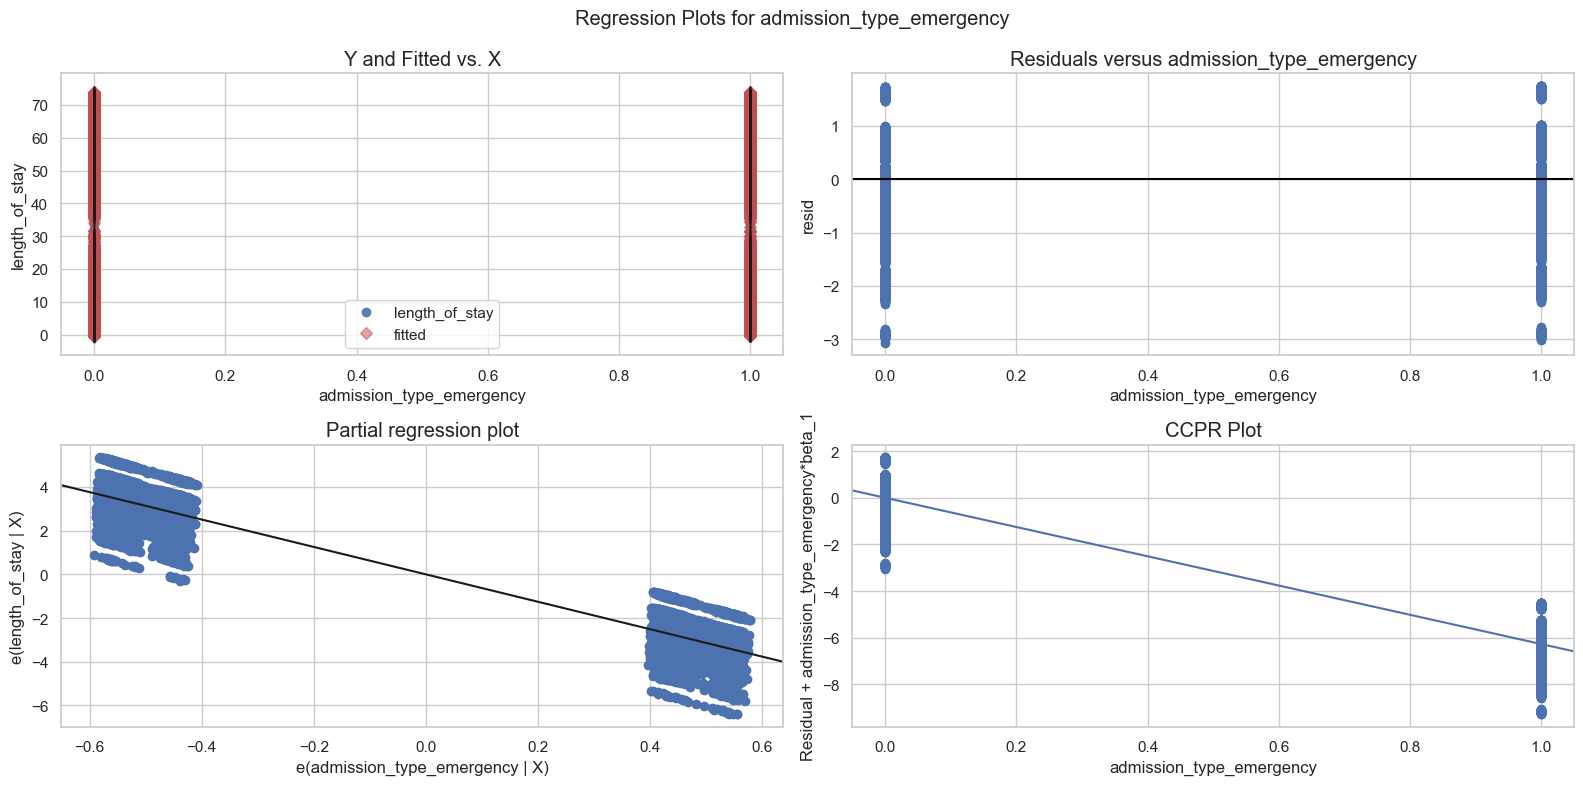

eval_env: 1


In [ ]:
# Residual Plots for all variables 

# Loop through each feature in the reduced model
for feature in reduced_X1.columns:
    # Modify figure size
    fig = plt.figure(figsize=(16, 8))
    
    # Regression plots for each feature in the reduced model
    sm.graphics.plot_regress_exog(reduced_model, feature, fig=fig)
    
    # Display plots
    plt.show()

### Model’s Residual Standard Error

In [ ]:
# Reduced Model's Residual Standard Error (RSE)

RSE = reduced_model.resid.std(ddof=X.shape[1])
print(f"Residual Standard Error (RSE): {RSE}")

<a id="e3"></a>
## E3. Implementation of Linear Regression Models

Please see the file 'd208_task1.ipynb' for an executable, error-free copy of the code used to support the implementation of the linear regression models. 

<a id="5"></a>
# Part V: Data Summary & Implications

<a id="f1"></a>
## F1. Results of Data Analysis

<a id="f1a"></a>
## A. Regression Equation


#### General Formula:
Following the general multiple linear regression equation (LaMorte, 2016): <br>

$
\hat{y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n
$

Where: <br>
- $\hat{y}$ is the predicted value of the dependent variable (in this case, length of stay)
- $\beta_0$ is the intercept (constant)
- $\beta_1 + \beta_2 + \dots + \beta_n$ are the regression coefficients for the independent variables ($X_1, X_2, \dots X_n$)

We derive our regression equation by using the coefficients provided in the OLS summary of our reduced model.

### Regression Equation:

Substituting our variables into the above formula, our regression equation becomes: <br>

$
\hat{y} = -5.5557 
- 6.2735 \cdot \text{admission_type_emergency} 
+ 5.0220 \cdot \text{complication_risk_level_low} 
+ 5.0149 \cdot \text{complication_risk_level_medium} 
− 0.9352 \cdot \text{diabetes}
−1.0422 \cdot \text{back_pain}
−1.3827 \cdot \text{high_bp}
+0.0604 \cdot \text{stroke}
+88.2075 \cdot \text{daily_charge}
$

#### Explanation of the Terms:
0. The intercept (constant): −5.5557
1. For **emergency admission: −6.2735** reduces the length of stay. 
2. For **low complication risk: +5.0220** increases the length of stay.
3. For **medium complication risk: +5.0149** increases the length of stay.
4. For **diabetes: −0.9352** reduces the length of stay.
5. For **back pain: −1.0422** reduces the length of stay.
6. For **high blood pressure (high_bp): −1.3827** reduces the length of stay.
7. For **stroke: +0.0604** slightly increases the length of stay.
8. For **daily charges**: Each unit increase in daily charges adds **88.2075** days to the length of stay.

This equation allows us to predict the length of stay based on these factors.

----

<a id="f1b"></a>
## B. Interpretation of the Coefficients of the Reduced Model
**1. Admission Type: Emergency (−6.2735)**
- **Interpretation:** Keeping all things constant, if a patient is admitted for an emergency, their length of stay decreases by 6.27 days compared to non-emergency admissions.

**2. Complication Risk Level: Low (+5.0220)**
- **Interpretation:** Keeping all things constant, patients with a low complication risk spend 5.02 more days hospitalized compared to those with a high complication risk.

**3. Complication Risk Level: Medium (+5.0149)**
- **Interpretation:** Keeping all things constant, patients with a medium complication risk spend 5.01 more days hospitalized compared to those with a high complication risk.

**4. Diabetes (−0.9352)**    
- **Interpretation:** Keeping all things constant, patients with diabetes spend 0.94 fewer days in the hospital compared to non-diabetic patients.

**5. Back Pain (−1.0422)**
- **Interpretation:** Keeping all things constant, patients with back pain spend 1.04 fewer days hospitalized compared to patients without back pain.

**6. High Blood Pressure (−1.3827)**
- **Interpretation:** Keeping all things constant, patients with high blood pressure stay 1.38 fewer days in the hospital compared to those without high blood pressure.

**7. Stroke (+0.0604)**
- **Interpretation:** Keeping all things constant, patients with a stroke stay 0.06 more days in the hospital compared to those without a stroke.

**8. Daily Charge (+88.2075)**
- **Interpretation:** Keeping all things constant, for each unit increase in daily hospital charges, the length of stay increases by 88.21 days.
    
### Summary of the Reduced Model Interpretation: 
- The **admission type (emergency)** has a significant negative effect on the length of stay, meaning emergency patients tend to have shorter hospitalizations.
- **Complication risk** (both low and medium) significantly increases the length of stay compared to high complication risk patients.
- **Diabetes, back pain, and high blood pressure** all reduce the length of stay.
- **Stroke** has a very small positive effect on the length of stay.
- **Daily charge** has a large and positive effect, though its magnitude suggests scaling issues that may require further investigation.

----

<a id="f1c"></a>
## C. Statistical and Practical Significance of the Reduced Model
**1. Admission Type: Emergency (6.27 days shorter stay)**

- **Statistical Significance:** The p-value of 0.000 indicates that the observed difference in length of stay for emergency patients is highly statistically significant.
- **Practical Significance:** Emergency patients experience a substantial reduction of 6.27 days in their hospital stays. This significant difference suggests that emergency cases are more efficiently treated and discharged, likely due to a focus on immediate care and rapid resolution.

**2. Complication Risk Level: Low +5.02 days, 3. Complication Risk Level: Medium +5.01 days**
- **Statistical Significance:** The p-value of 0.000 for both low and medium complication risk levels indicates a highly significant association with increased length of stay.
- **Practical Significance:** Patients with low or medium complication risk remain in the hospital for approximately 5 days longer than those with high risk. This unexpected finding suggests that high-risk patients may be discharged earlier, possibly due to deteriorating health conditions or transfers to facilities with specialized care. Further research is necessary to explore the underlying reasons for this observation.

**4. Diabetes (0.94 days shorter stay)**    
- **Statistical Significance:** The p-value of 0.000 indicates a highly significant association between diabetes and reduced length of stay.
- **Practical Significance:** Diabetic patients spend nearly 1 day less in the hospital compared to non-diabetic patients. This clinically meaningful difference suggests that effective diabetes management may contribute to faster discharge, potentially through standardized treatment approaches and efficient care coordination.

**5. Back Pain (1.04 days shorter stay)**
- **Statistical Significance:** The p-value of 0.000 indicates a highly significant association between back pain and reduced length of stay.
- **Practical Significance:** Patients with back pain spend 1 day less in the hospital. Given the prevalence of back pain, this significant finding has important implications for hospital bed management and the development of more efficient treatment approaches for these patients.

**6. High Blood Pressure (1.38 days shorter stay)**
- **Statistical Significance:** The p-value of 0.000 indicates a highly significant association between high blood pressure and reduced length of stay.
- **Practical Significance:** Patients with high blood pressure spend 1.38 less days in the hospital. While statistically significant, this reduction is also practically meaningful, especially considering the prevalence of high blood pressure. Shorter stays could contribute to improved overall hospital efficiency.

**7. Stroke (0.06 days longer stay)**
- **Statistical Significance:** Although this coefficient is positive and statistically significant (p-value = 0.014), the effect is very small. 
- **Practical Significance:** The increase in length of stay for stroke patients is negligible (only 0.06 days). Despite statistical significance, this effect has minimal practical impact, indicating that stroke does not substantially affect the length of hospitalization in this dataset.

**8. Daily Charge (88.21 increase in length of stay/unit)**
- **Statistical Significance:** The p-value of 0.000 indicates a highly significant association between daily charge and length of stay, but the unusually large coefficient suggests potential scaling issues (charges might be recorded in thousands of dollars).
- **Practical Significance:** The extremely large coefficient for daily charge indicates that increases in hospital charges are strongly associated with longer stays (88.21 days per unit increase). However, this might be due to scaling issues, as the daily charge variable could be measured in large units (thousands of dollars). If the scaling is correct, this effect could be meaningful, but it's essential to confirm how charges are recorded.
    
### Summary of the Statistical and Practical Significance of the Reduced Model:
**Statistical Significance:** <br>
- The reduced model, as a whole, and each of its individual coefficients are statistically significant, confirming a strong relationship between the predictors and length of stay.

**Practical Significance:** 
- Variables like daily charge, admission type (emergency), and complication risk levels have significant practical impacts on length of stay. Daily charge, in particular, has the most substantial effect, although scaling issues should be investigated further.
- Diabetes, back pain, and high blood pressure show moderate practical significance, with meaningful reductions in length of stay that can impact hospital management.
- Stroke, despite statistical significance, has a negligible practical impact due to its very small effect size.

----

<a id="f1d"></a>
## D. Limitations of the Analysis
### Regression Modeling Limitations
**Sensitivity to Outliers** 

Regression analysis, especially the Ordinary Least Squares (OLS) method, "is subject to errors associated to heteroscedasticity and the presence of outliers., is sensitive to outliers" (Tedeschi, 2023). A single extreme data point can significantly distort the results by affecting the slope of the regression line. Outliers can lead to misleading coefficient estimates, inflated standard errors, and unreliable p-values.

**Correlation Does Not Imply Causation**

A significant relationship between our independent and dependent variables does not necessarily imply causation. Without controlled experimentation or additional context, our regression results can only show associations, not cause-and-effect relationships. Misinterpreting correlation as causation can result in incorrect conclusions.

**Multicollinearity**

As we've previously seen, when independent variables are highly correlated, multicollinearity arises, inflating coefficient estimate variance and making it difficult to determine each predictor's individual effect. While not always problematic, high multicollinearity can destabilize model coefficients, making them "sensitive to small changes in the model." This can lead to "reduced precision of the estimated coefficients," weakening the statistical power of our regression model and resulting in large standard errors that may render our results meaningless (Frost, 2023).

**Linearity Assumption**

Linear regression assumes a linear relationship between the independent and dependent variables. In many real-world situations, however, this assumption simply does not hold; and the true relationship might actually be non-linear. If the linearity assumption is violated, our model may not fit the data well, resulting in biased estimates and poor predictive performance.

### Data Preparation Limitations
**Inadequate Data Exploration**

Insufficient exploratory data analysis (EDA) can hinder our understanding of variable relationships, overlooking key features like non-linear relationships, outliers, or unusual patterns. If we've failed to thoroughly explore the data, this can result in poorly specified models that inaccurately capture variable relationships.

**Data Wrangling Errors**

Incorrect data transformations, such as encoding our categorical variables incorrectly or failing to normalize continuous variables, can lead to biased results or other errors.

### Model Reduction Method Limitations

**Overfitting** 

Using many predictors as we have done can lead to overfitting, where the model captures noise rather than the underlying relationship, resulting in poor generalization to new data. Overfitted models may perform well on training data but fail on validation or test data, reducing their actual practical utility.

**Multicollinearity After Reduction**

Our model reduction techniques might not correctly resolve multicollinearity, especially if we don't account for variable correlations. Multicollinearity can still inflate standard errors and make it difficult for us to interpret the reduced model.

----

<a id="f2"></a>
## F2. Recommendations

### Answering the Research Question

Which <mark>patient characteristics or comorbidities most significantly influence their length of stay</mark> in our hospital? 

#### Patient Characteristics and Comorbidities Influencing Length of Stay

Based on our regression analysis, we've found that the following patient characteristics and comorbidities significantly influence length of stay in our hospital:

- <mark>**Admission Type**</mark>: Emergency admissions are associated with significantly shorter stays, suggesting they are typically more urgent and require less extended care.
- <mark>**Complication Risk**</mark>: Patients with low or medium complication risk tend to have longer stays compared to those with high risk, possibly indicating more extensive care requirements.
- Comorbidities: <mark>**Diabetes, back pain, and high blood pressure**</mark> are generally associated with shorter stays, suggesting that effective management of these conditions can contribute to quicker recovery and discharge.
- <mark>**Daily Charges**</mark>: While scaling issues should be investigated, higher daily charges are associated with longer stays, potentially indicating that more expensive care, involving more intensive services, results in extended hospitalizations.

Overall, our findings suggest that <mark>**emergency admissions, complication risk levels, and the effective management of certain comorbidities are key factors influencing length of stay**.</mark> Knowing this and understanding these factors can help us better manage our hospital resource allocation, treatment protocols, and patient management strategies to optimize length of stay for different patient groups.

### Recommended Action

Given the practical significance of our regression model, the next step is to validate the model's performance to ensure it generalizes well beyond the sample data and performs effectively on new, unseen data. We can do this by splitting the dataset into training and test subsets. A common approach that we can follow is to do an 80/20 train-test split, allocating 80% of the data to a training set (to train the model) and the remaining 20% to the test set (to evaluate the model's performance and generalization capabilites). With these subsets, we can retrain the model on the training set, evaluating its performance on the test set using metrics like R-squared, Mean Squared Error (MSE), or Root Mean Squared Error (RMSE) to assess whether the model's predictive power holds up when applied to new data and ensure it's not overfitted to the training data. 

<a id="6"></a>
# Part VI: Demonstration

<a id="g"></a>
## G. Panopto Video Recording

Panopto video recording: [https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=004704d3-b35b-4067-a7a1-b1f80126d889#](https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=004704d3-b35b-4067-a7a1-b1f80126d889#)

<a id="h"></a>
## H. Data & Code Sources
- Western Governors University. (2023). *Medical Data and Dictionary Files* [Dataset]. Data Files and Associated Dictionary Files.
    - Retrieved March 25, 2024, from
	- [https://access.wgu.edu/ASP3/aap/content/g9rke9s0rlc9ejd92md0.html](https://access.wgu.edu/ASP3/aap/content/g9rke9s0rlc9ejd92md0.html) 
- GeeksforGeeks (2022, February 21). *How to Create a Residual Plot in Python.* [Source code]. 
    - Retrieved September 18, 2024, from
    - [geeksforgeeks.org/how-to-create-a-residual-plot-in-python](https://www.geeksforgeeks.org/how-to-create-a-residual-plot-in-python/)

<a id="i"></a>
# I. References
- Bhandari, A. (2024, September 18). *What is Multicollinearity? | Causes, Effects and Detection Using VIF.* Analytics Vidhya.  
    - Retrieved September 20, 2024, from
    - [analyticsvidhya.com/blog/2020/03/what-is-multicollinearity](https://www.analyticsvidhya.com/blog/2020/03/what-is-multicollinearity/)
- Brownlee, J. (2020, August 28). *How to Use StandardScaler and MinMaxScaler Transforms in Python.* Machine Learning Mastery.  
    - Retrieved September 20, 2024, from
    - [machinelearningmastery.com/standardscaler-and-minmaxscaler-transforms-in-python](https://machinelearningmastery.com/standardscaler-and-minmaxscaler-transforms-in-python/)
- Calculator.name (2021). *Convert Scientific Notation to Decimal.* [Online Calculator].
    - Retrieved September 18, 2024, from
    - [calculator.name/scientific-notation/scientific-notation-to-decimal.php](https://calculator.name/scientific-notation/scientific-notation-to-decimal.php)
- GeeksforGeeks (2022, February 21). *How to Create a Residual Plot in Python.*
    - Retrieved September 18, 2024, from
    - [geeksforgeeks.org/how-to-create-a-residual-plot-in-python](https://www.geeksforgeeks.org/how-to-create-a-residual-plot-in-python/)
- Frost, J. (2023, January 29). *Multicollinearity in Regression Analysis: Problems, Detection, and Solutions.* Statistics by Jim.
    - Retrieved September 19, 2024, from
    - [statisticsbyjim.com/regression/multicollinearity-in-regression-analysis](https://statisticsbyjim.com/regression/multicollinearity-in-regression-analysis/)
- LaMorte, W.W. (2013, January 17). *Multivariate Methods.* Multiple Logistic Regression Analysis.
    - Retrieved September 19, 2024, from
    - [sphweb.bumc.bu.edu/otlt/mph-modules/bs/bs704-ep713_multivariablemethods/bs704-ep713_multivariablemethods2.html](https://sphweb.bumc.bu.edu/otlt/mph-modules/bs/bs704-ep713_multivariablemethods/bs704-ep713_multivariablemethods2.html)
- LaMorte, W.W. (2016, May 31). *Multivariate Methods.* The Multiple Linear Regression Equation.
    - Retrieved September 19, 2024, from
    - [sphweb.bumc.bu.edu/otlt/mph-modules/bs/bs704_multivariable/bs704_multivariable8.html](https://sphweb.bumc.bu.edu/otlt/mph-modules/bs/bs704_multivariable/bs704_multivariable8.html)
- Middleton, K. (2023, July 13). *Getting Started with D208 Part II.* [PowerPoint slides]. Western Governors University.
    - Retrieved September 19, 2024, from
    - [westerngovernorsuniversity.sharepoint.com/sites/DataScienceTeam/Shared%20Documents/Forms/AllItems.aspx?csf=1&web=1&e=9ccodm&CID=5a1cbaff%2D9e51%2D432e%2D9ba0%2D22fa5b695ab7&FolderCTID=0x01200022092E63FD85A64A8ABFB4F5AEA4839A&id=%2Fsites%2FDataScienceTeam%2FShared%20Documents%2FGraduate%20Team%2FD208%2FStudent%20Facing%20Resources](https://westerngovernorsuniversity.sharepoint.com/sites/DataScienceTeam/Shared%20Documents/Forms/AllItems.aspx?csf=1&web=1&e=9ccodm&CID=5a1cbaff%2D9e51%2D432e%2D9ba0%2D22fa5b695ab7&FolderCTID=0x01200022092E63FD85A64A8ABFB4F5AEA4839A&id=%2Fsites%2FDataScienceTeam%2FShared%20Documents%2FGraduate%20Team%2FD208%2FStudent%20Facing%20Resources)
- Purdue OWL. (2024). *APA Formatting and Style Guide (7th Edition).* Purdue University.
    - Retrieved September 20, 2024, from
    - [owl.purdue.edu/owl/research_and_citation/apa_style/apa_formatting_and_style_guide](https://owl.purdue.edu/owl/research_and_citation/apa_style/apa_formatting_and_style_guide/)
- Srinidhi, S. (2019, November 15). *Backward Elimination for Feature Selection in Machine Learning.* Medium.
    - [towardsdatascience.com/backward-elimination-for-feature-selection-in-machine-learning-c6a3a8f8cef4](https://towardsdatascience.com/backward-elimination-for-feature-selection-in-machine-learning-c6a3a8f8cef4)
- Statsmodels (2024, September 16). *Statsmodels 0.14.3.* 
    - Retrieved September 18, 2024, from
    - [statsmodels.org/stable/generated/statsmodels.graphics.regressionplots.plot_regress_exog.html](https://www.statsmodels.org/stable/generated/statsmodels.graphics.regressionplots.plot_regress_exog.html)
- Tedeschi, L.O. & Galyean, M.L. (2023, April 27). *A Practical Method to Account for Outliers in Simple Linear Regression Using the Median of Slopes.* 
    - Retrieved September 19, 2024, from
    - [scielo.br/j/sa/a/FV3StxT4v8Y78ZBBRnYKDPd](https://www.scielo.br/j/sa/a/FV3StxT4v8Y78ZBBRnYKDPd/?format=pdf&lang=en#:~:text=The%20ordinary%20least%20squares%20(OLS)%20is%20the%20standard%20method%20of,the%20median%20of%20the%20slopes)
- Matplotlib (2017, May 10). *Color Example Code.* [Color Map].
    - Retrieved September 17, 2024, from
    - [matplotlib.org/2.0.2/examples/color/named_colors.html](https://matplotlib.org/2.0.2/examples/color/named_colors.html)
- Valchanov, I. & Ganchev, M. (2024). *Advanced Statistical Methods - Multiple Linear Regression with StatsModels.* [MOOC]. Udemy. 
    - Retrieved September 18, 2024, from
    - [udemy.com/course/the-data-science-course-complete-data-science-bootcamp/learn](https://www.udemy.com/course/the-data-science-course-complete-data-science-bootcamp/learn)    
- Weir, C.B. & Jan, A. (2023, June 26). *BMI Classification Percentile and Cut Off Points.* National Library of Medicine.
    - Retrieved September 3, 2024, 2024, from 
	- [https://www.ncbi.nlm.nih.gov/books/NBK541070/](https://www.ncbi.nlm.nih.gov/books/NBK541070/) 
- World Health Organization.  (2023, March 16). *Hypertension.* Healthline.
    - Retrieved September 4, 2024, from 
	- [https://www.who.int/news-room/fact-sheets/detail/hypertension](https://www.who.int/news-room/fact-sheets/detail/hypertension)